# Insurance Fraud Data — Preprocessing Pipeline (Enhanced)

This version extends the original preprocessing notebook with:
- Engineered features (claim ratio, vehicle age group, income group, weekend claim, claim/vehicle-age ratio)
- Removal of ID-like columns that add noise
- Imputation instead of blanket `dropna()` so fewer rows are thrown away
- Outlier **capping / winsorization / log-transform** instead of hard row removal
- Feature scaling
- Feature selection with `SelectKBest` (mutual information) and Random Forest importances

This notebook does **no train/test splitting and no hyperparameter tuning** — it produces a single preprocessed, scaled CSV. Splitting and model tuning happen downstream in whichever modeling notebook consumes this file.

## 1. Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

## 2. Load Data

In [20]:
df = pd.read_csv("insurance_fraud_data.csv")
df.rename(columns={
    "policy deductible": "policy_deductible",
    "annual premium": "annual_premium",
    "days open": "days_open",
    "form defects": "form_defects",
    "fraud reported": "fraud_reported"
}, inplace=True)
df.shape

(12002, 29)

## 3. Remove Unnecessary / Identifier Columns
Identifier-like columns don't carry predictive signal and mostly add noise, so they are dropped early. `errors="ignore"` makes this safe even if a column isn't present in this particular export of the dataset.

In [21]:
id_like_columns = ["claim_number", "policy_number", "customer_id", "zip_code"]
df.drop(columns=id_like_columns, inplace=True, errors="ignore")
df.shape

(12002, 27)

## 4. Clean Missing Value Placeholders & Fix Dtypes
`*` is used as a placeholder for missing data across several columns, so it is unified to `NaN` first. Numeric-looking columns that were read in as text are converted to numeric.

In [22]:
df.replace("*", np.nan, inplace=True)

# Columns that are genuinely categorical / text and must stay as-is
known_categorical = {
    "gender", "property_status", "claim_day_of_week", "accident_site",
    "channel", "vehicle_color", "vehicle_category", "claim_date", "fraud_reported"
}

# Any other object column that is actually numeric (often turned into text because the
# "*" placeholder forced pandas to read the whole column as strings) gets coerced back.
for col in df.columns:
    if col in known_categorical:
        continue
    # Covers classic "object" dtype as well as pandas >= 3.0's dedicated string dtype
    if not pd.api.types.is_numeric_dtype(df[col]):
        coerced = pd.to_numeric(df[col], errors="coerce")
        # Only adopt the coercion if it did not blow every value away
        if coerced.notna().sum() > 0:
            df[col] = coerced

# The target itself must be present — rows without a label can't be used for training
df.dropna(subset=["fraud_reported"], inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(11994, 27)

## 5. Date Feature Extraction

In [23]:
df["claim_date"] = pd.to_datetime(df["claim_date"], format="%m/%d/%Y", errors="coerce")
df["claim_year"] = df["claim_date"].dt.year
df["claim_month"] = df["claim_date"].dt.month
df["claim_day"] = df["claim_date"].dt.day
df.drop(columns=["claim_date"], inplace=True)

## 6. Create Better Features
Engineered features that often capture patterns the raw columns miss on their own.

In [24]:
# Claim ratio: how large the claim is relative to what the customer pays annually
df["claim_ratio"] = df["total_claim"] / df["annual_premium"]

# Vehicle age group: flag older vehicles
df["vehicle_old"] = (df["age_of_vehicle"] > 10).astype(int)

# Income category: bucket income into quartiles (kept as its own categorical feature)
df["income_group"] = pd.qcut(df["annual_income"], 4, duplicates="drop").astype(str)

# Weekend claim: claims filed on a weekend can behave differently
df["weekend_claim"] = df["claim_day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Claim per vehicle age: normalizes claim size by how old the vehicle is
df["claim_vehicle_ratio"] = df["total_claim"] / (df["age_of_vehicle"] + 1)

df[["claim_ratio", "vehicle_old", "income_group", "weekend_claim", "claim_vehicle_ratio"]].head()

,claim_ratio,vehicle_old,income_group,weekend_claim,claim_vehicle_ratio
0,18.930335,0,"(56899.2, 60899.2]",1,2959.253132
1,18.864665,0,"(-1.601, 56899.2]",0,8902.486737
2,12.738766,0,"(64699.2, 257313.6]",1,1909.923229
3,29.506206,0,"(64699.2, 257313.6]",1,10454.638860
4,29.036314,0,"(56899.2, 60899.2]",0,4927.711424


## 7. Better Missing Value Handling
Instead of dropping every row with a missing value (`dropna()`), remaining gaps are imputed — median for numeric columns, most-frequent for categorical columns — which keeps more rows in the dataset. `claim_ratio` and `claim_vehicle_ratio` can produce `inf` values when a denominator is zero; those are treated as missing before imputation.

In [25]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_all = df.select_dtypes(exclude=np.number).columns.tolist()
if "fraud_reported" in categorical_cols_all:
    categorical_cols_all.remove("fraud_reported")

num_imputer = SimpleImputer(strategy="median")
df[numeric_cols_all] = num_imputer.fit_transform(df[numeric_cols_all])

if categorical_cols_all:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[categorical_cols_all] = cat_imputer.fit_transform(df[categorical_cols_all])

df.isna().sum().sum(), df.shape

(np.int64(0), (11994, 34))

## 8. Outlier Inspection

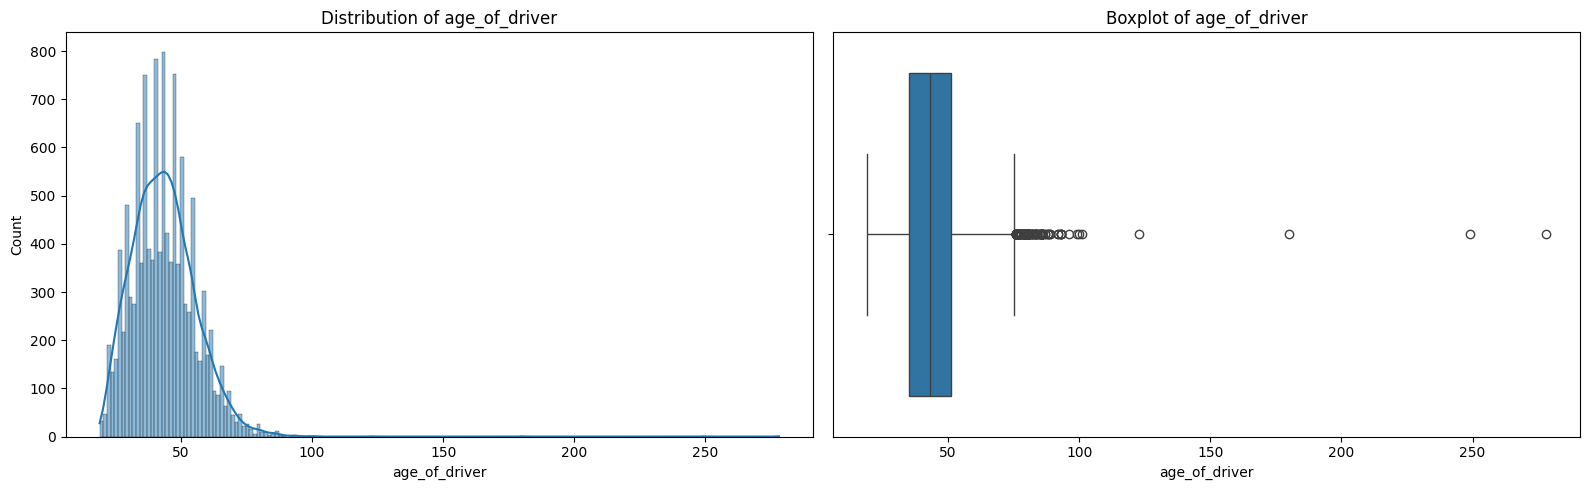

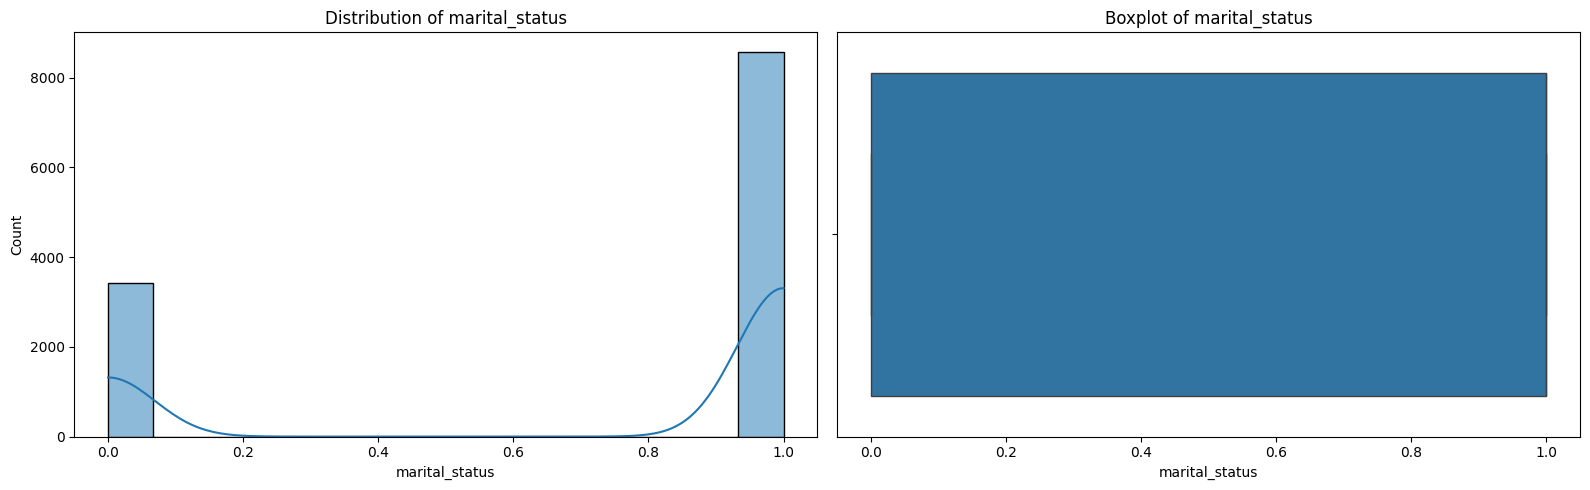

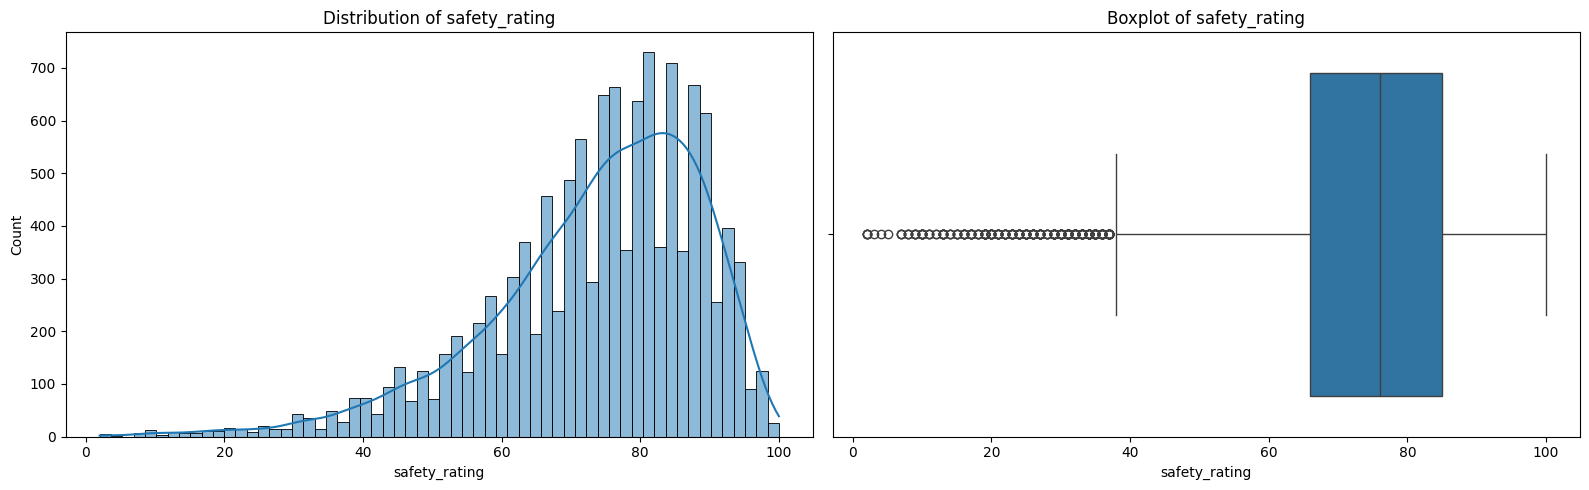

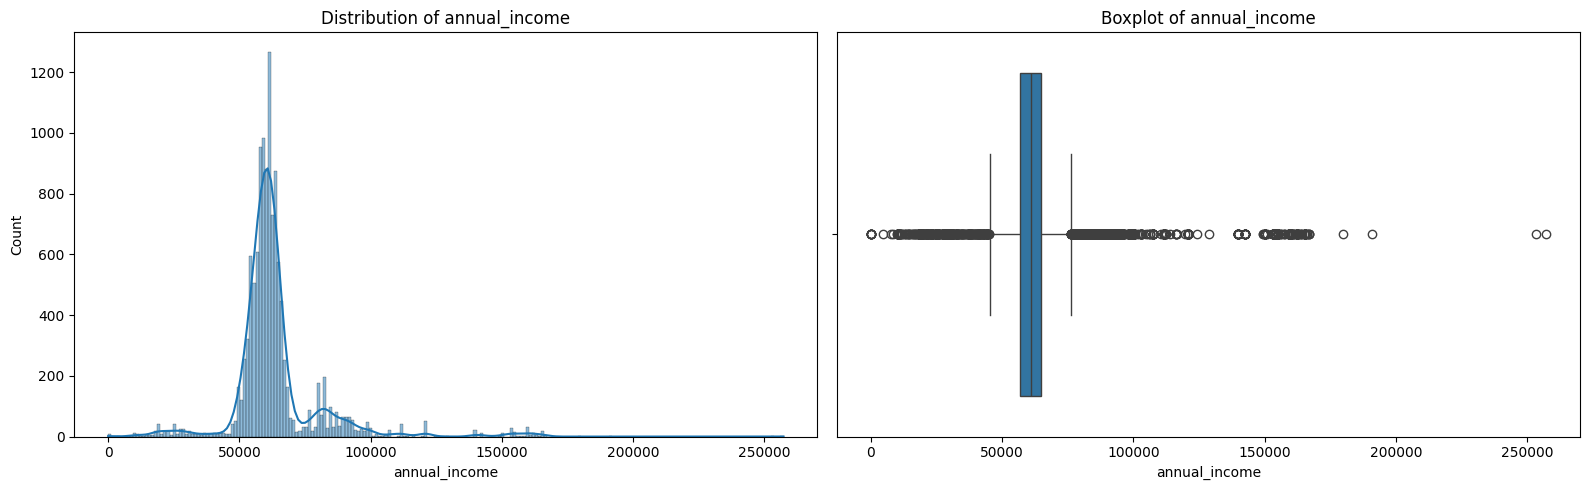

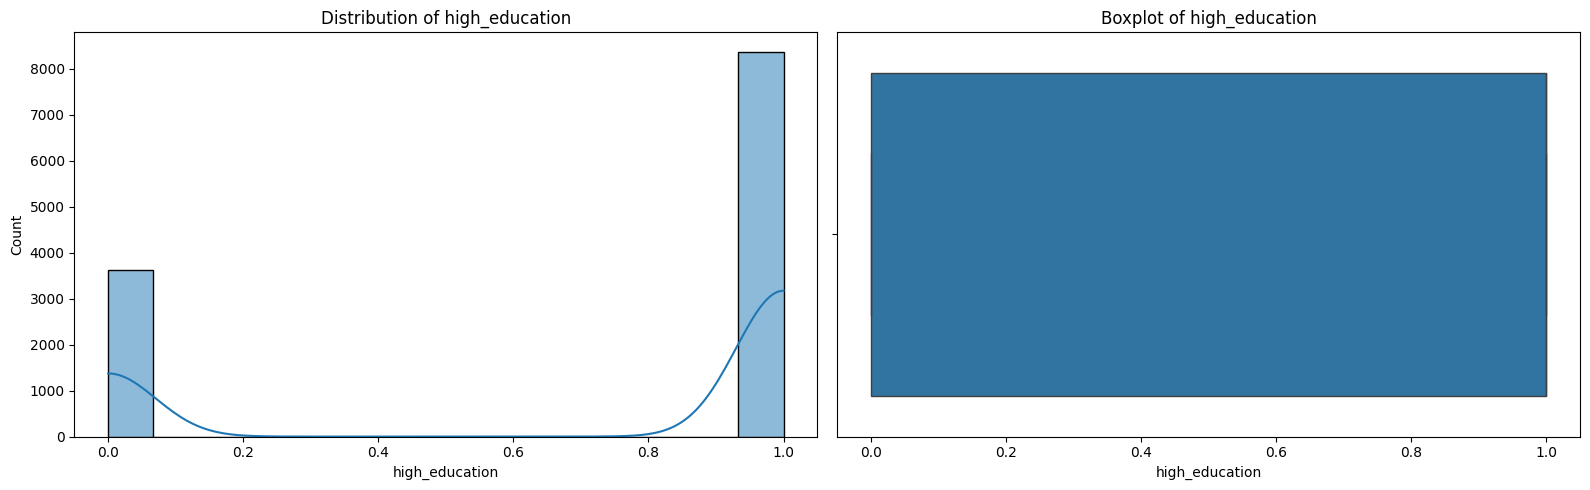

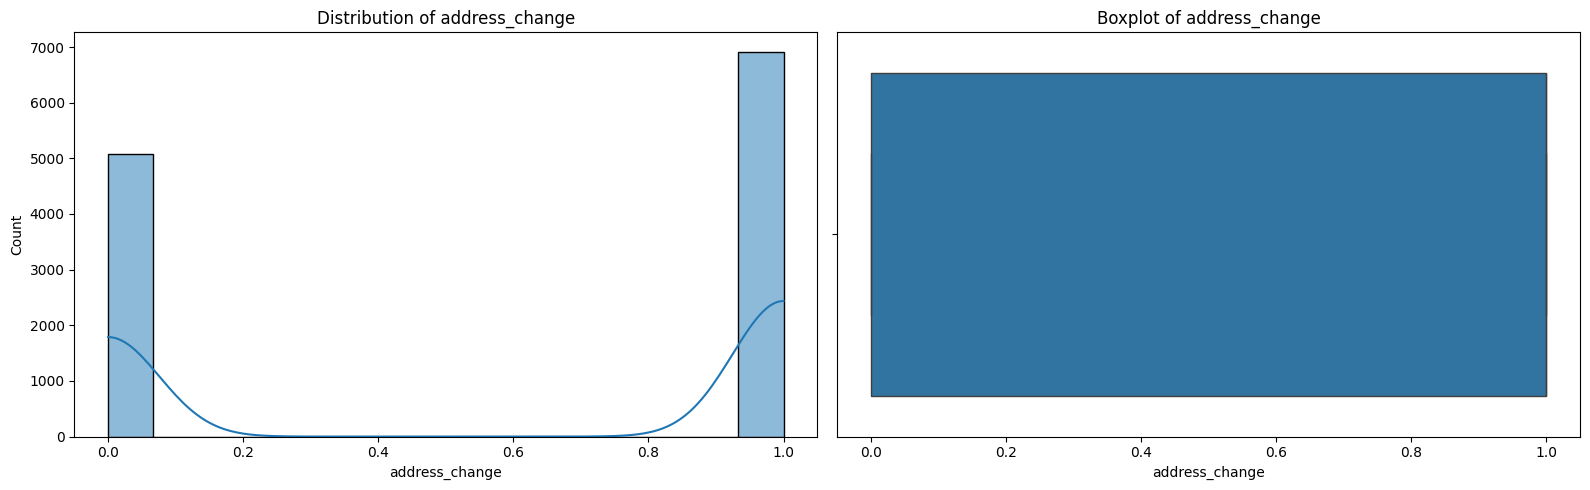

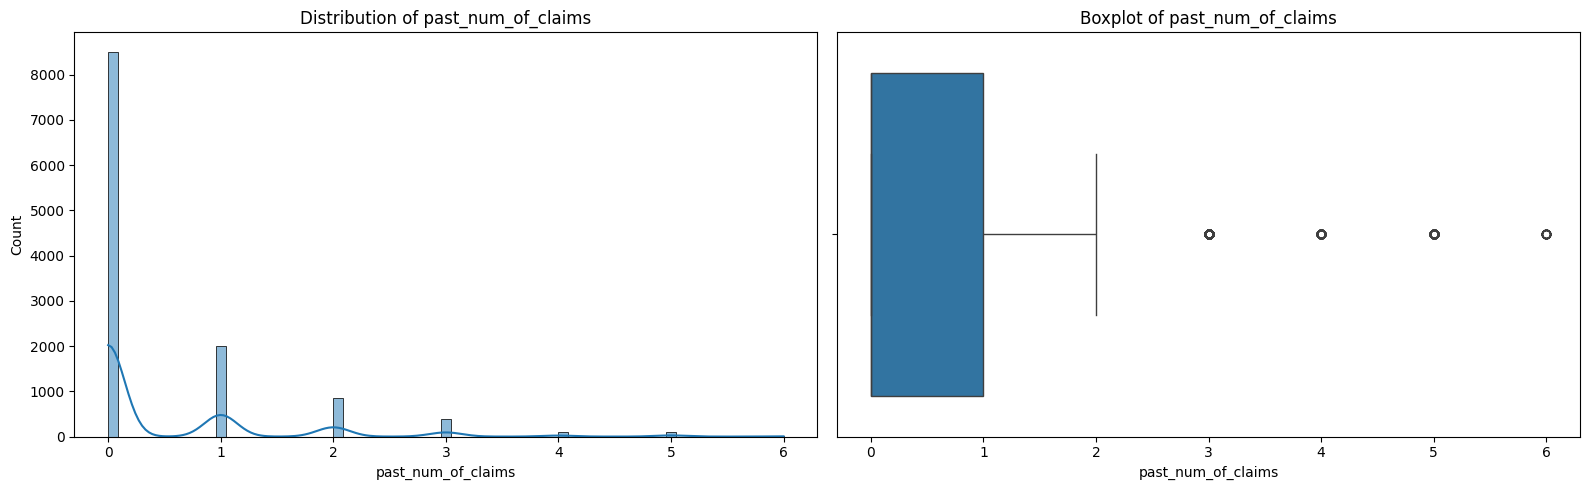

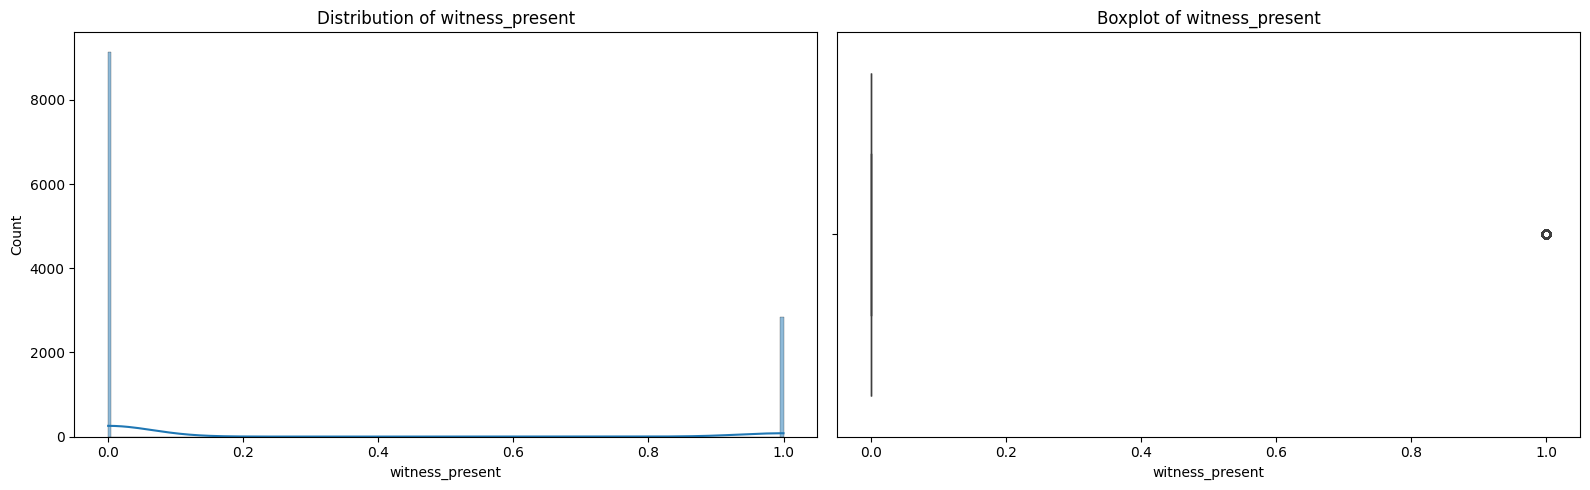

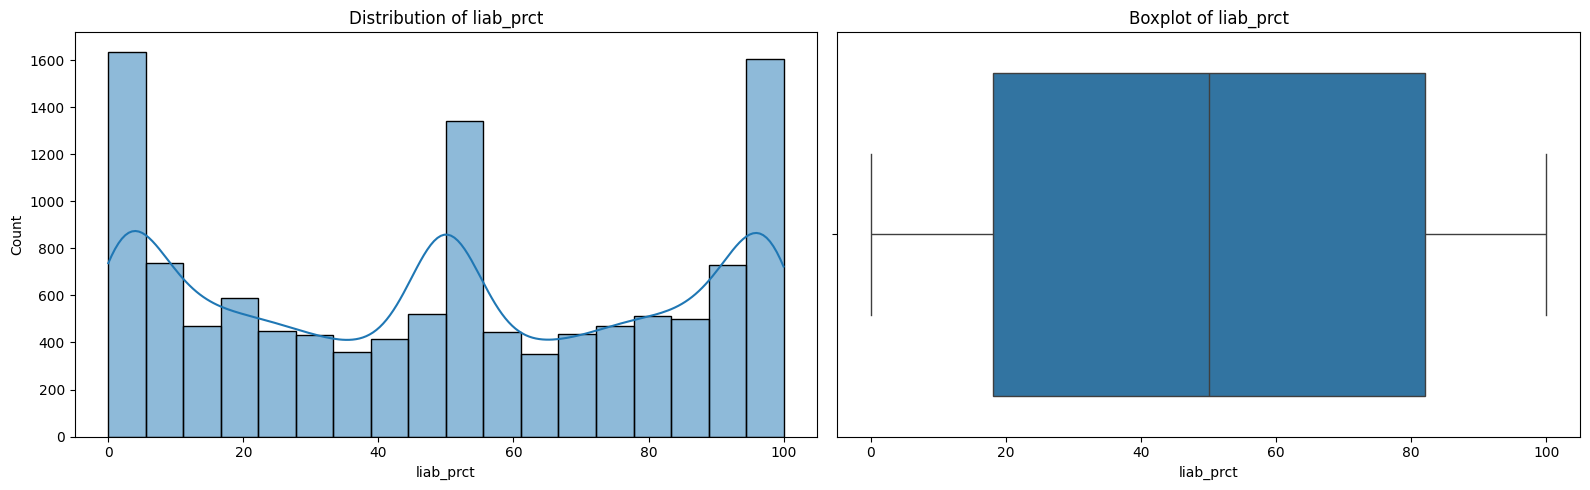

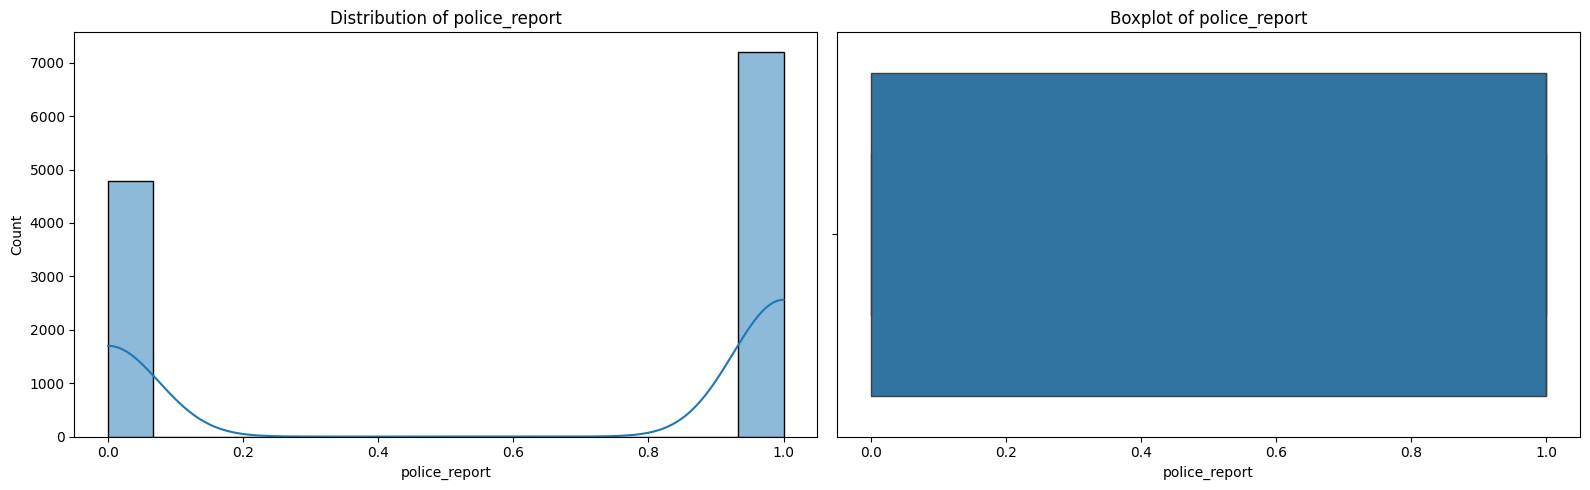

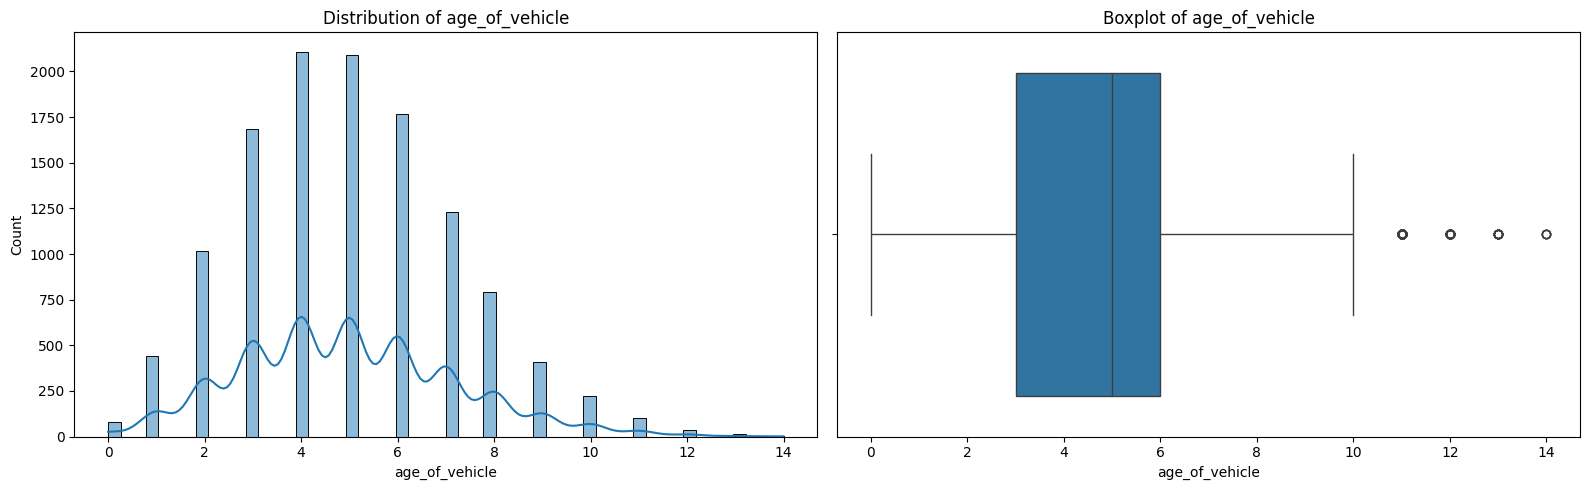

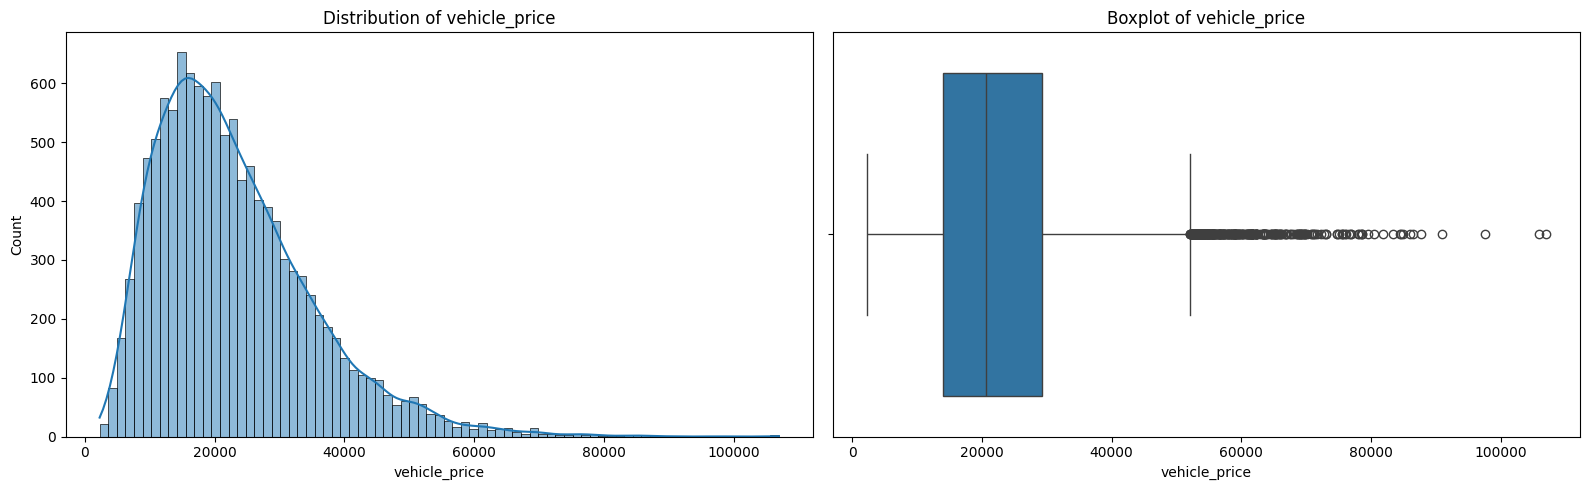

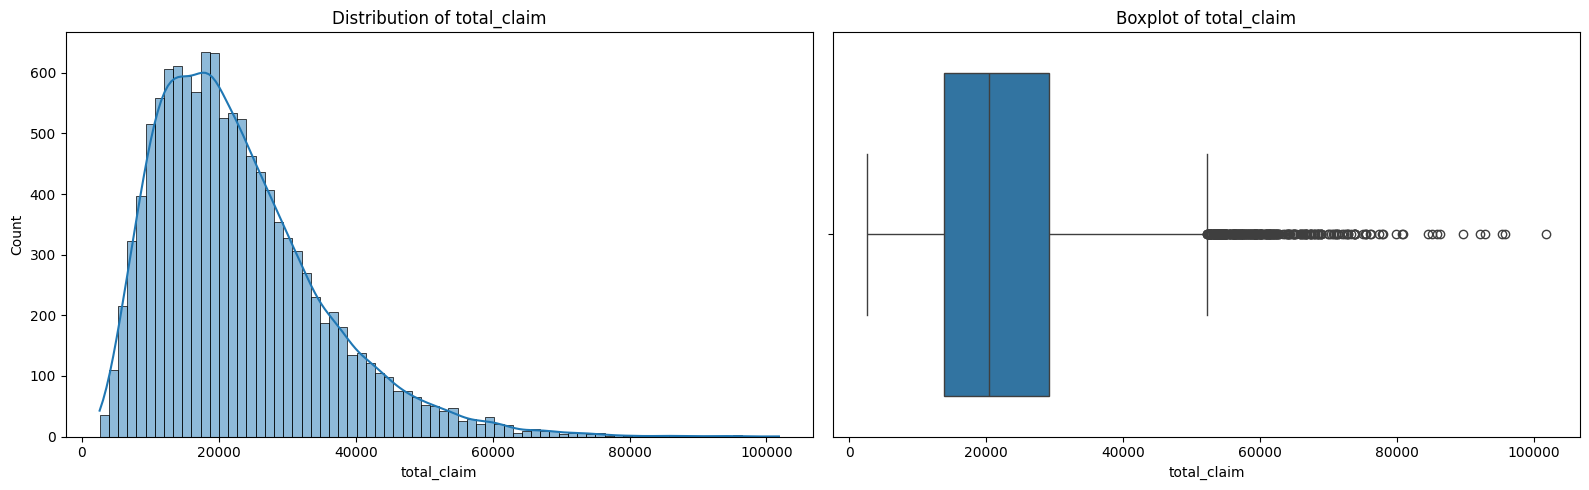

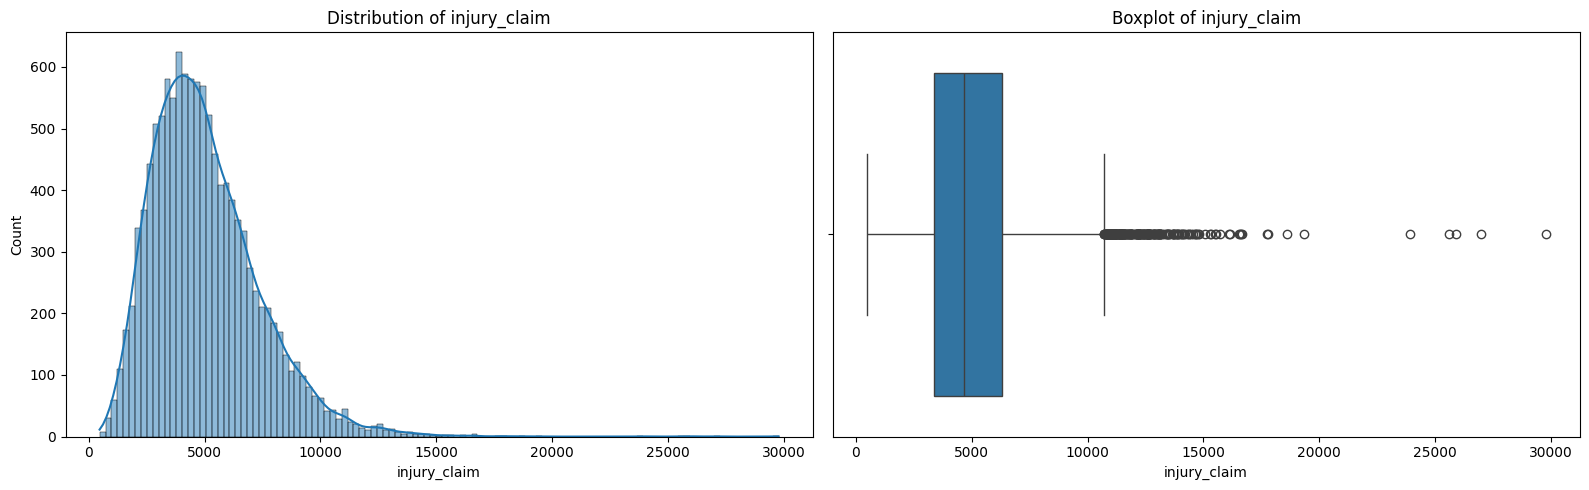

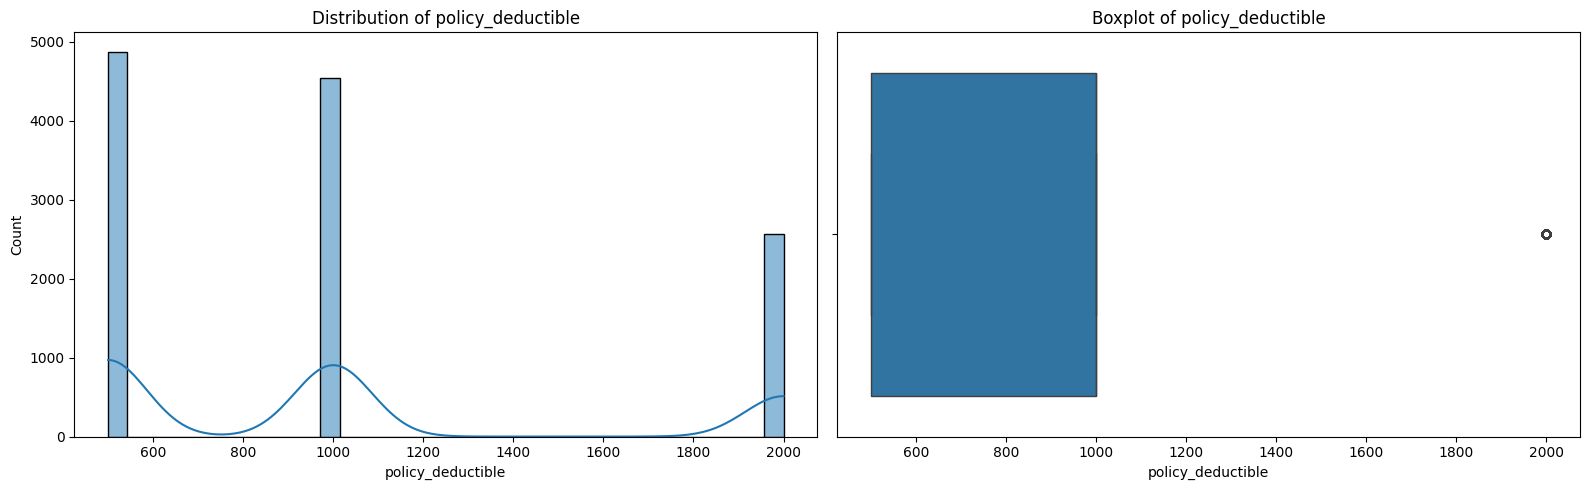

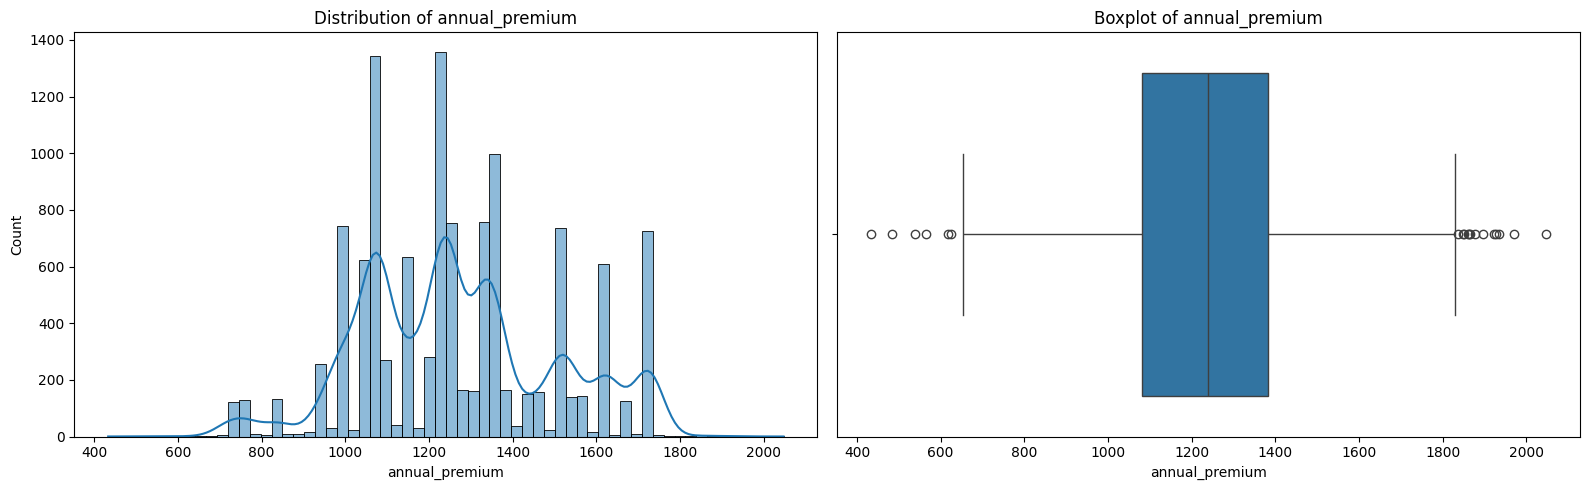

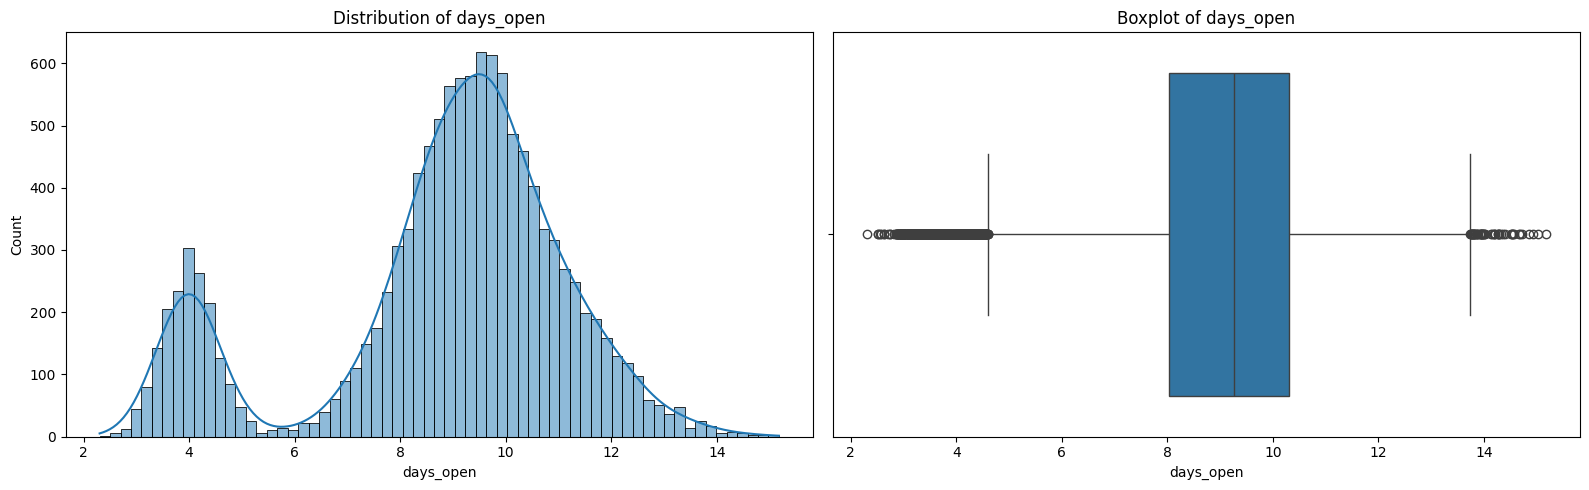

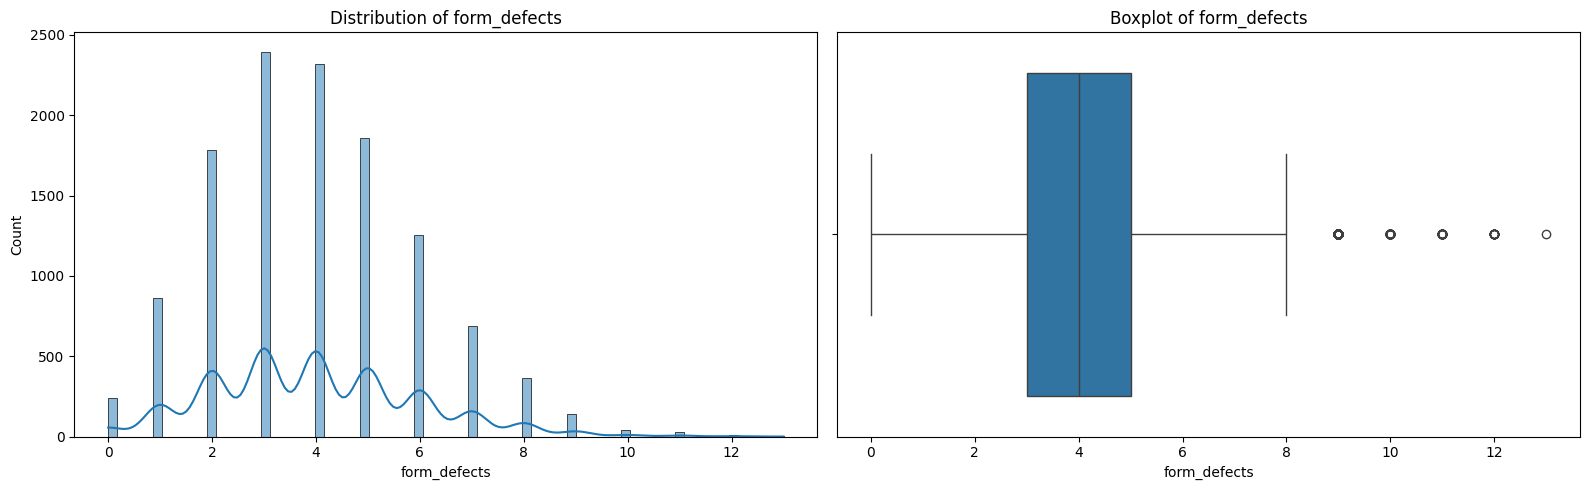

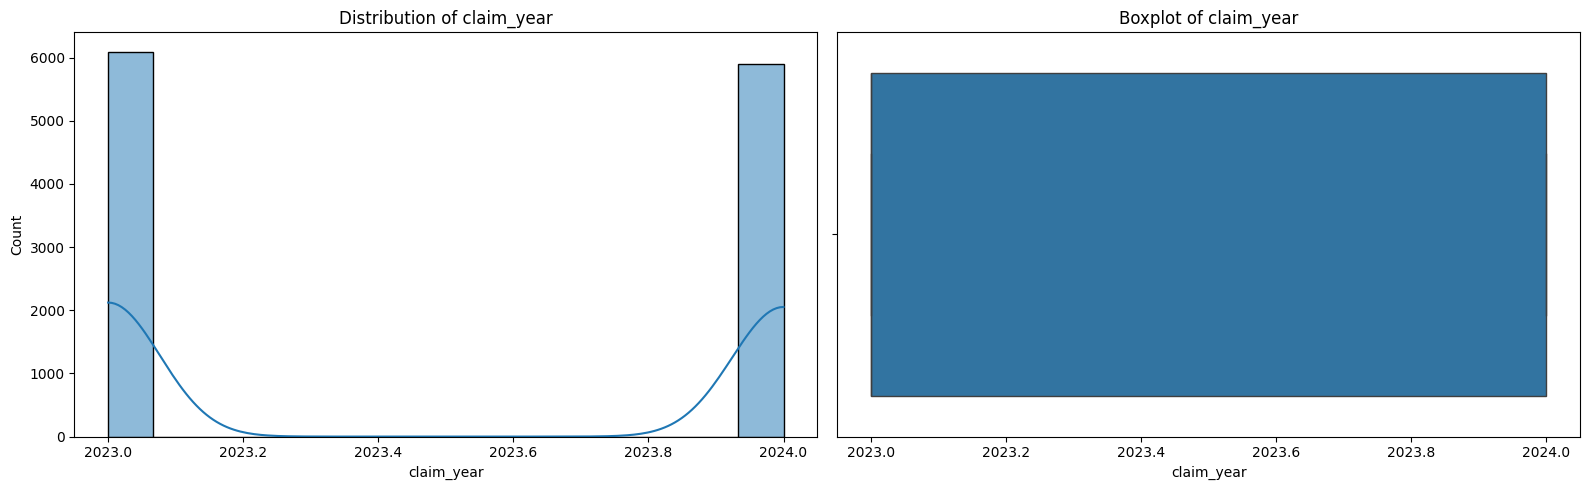

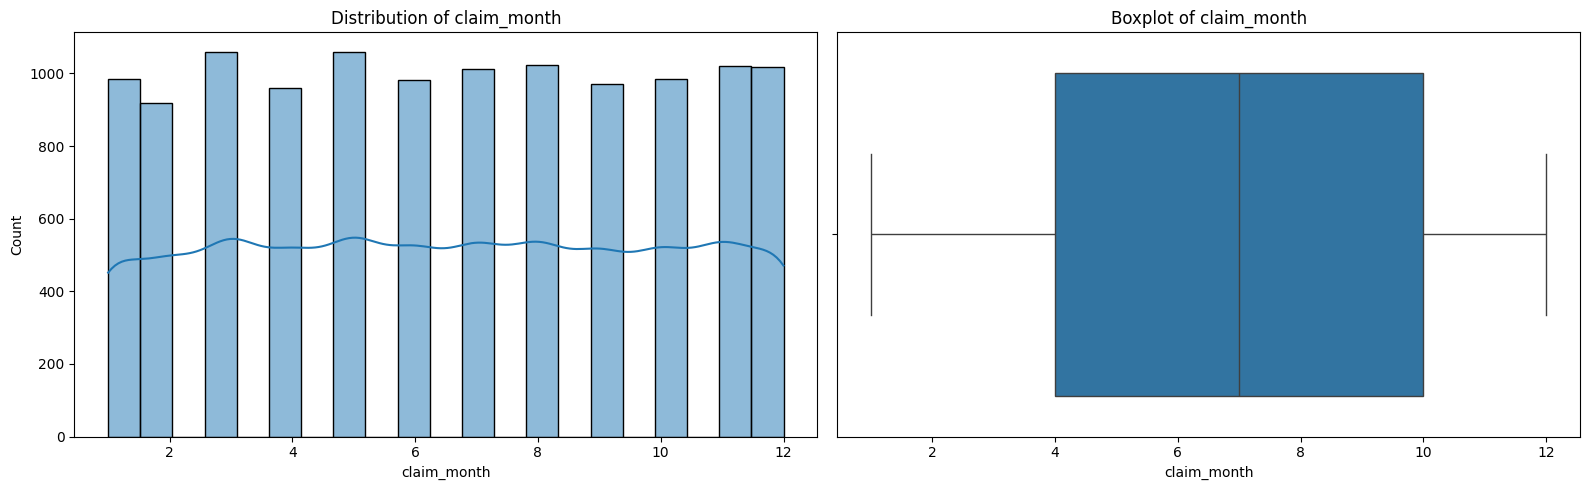

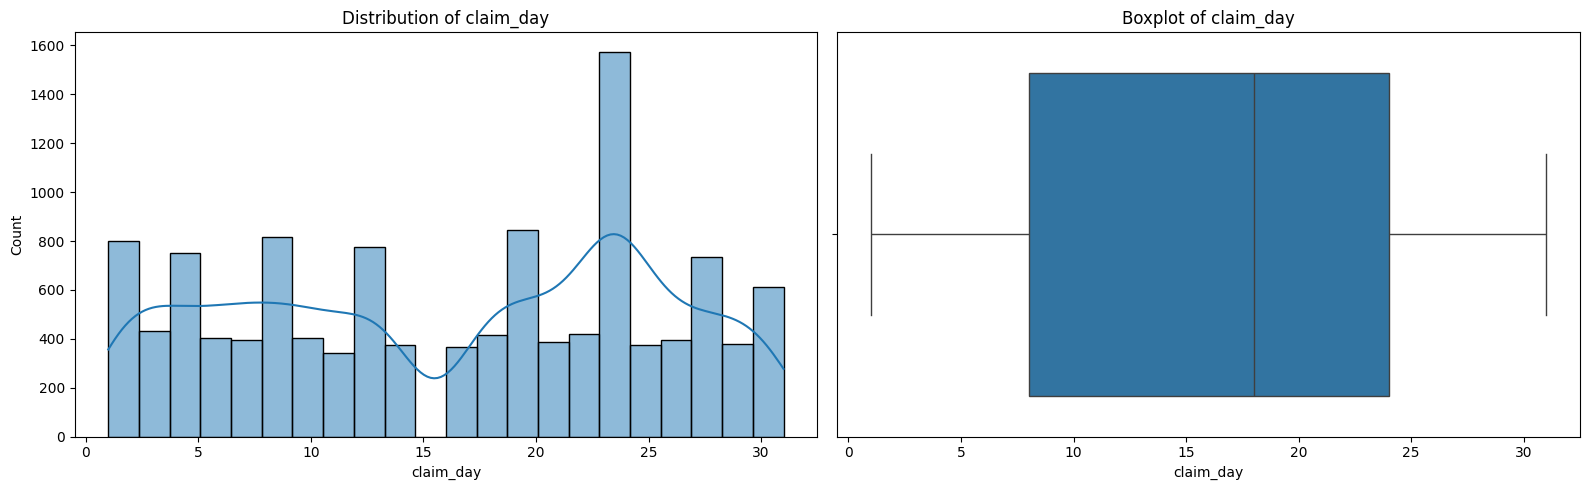

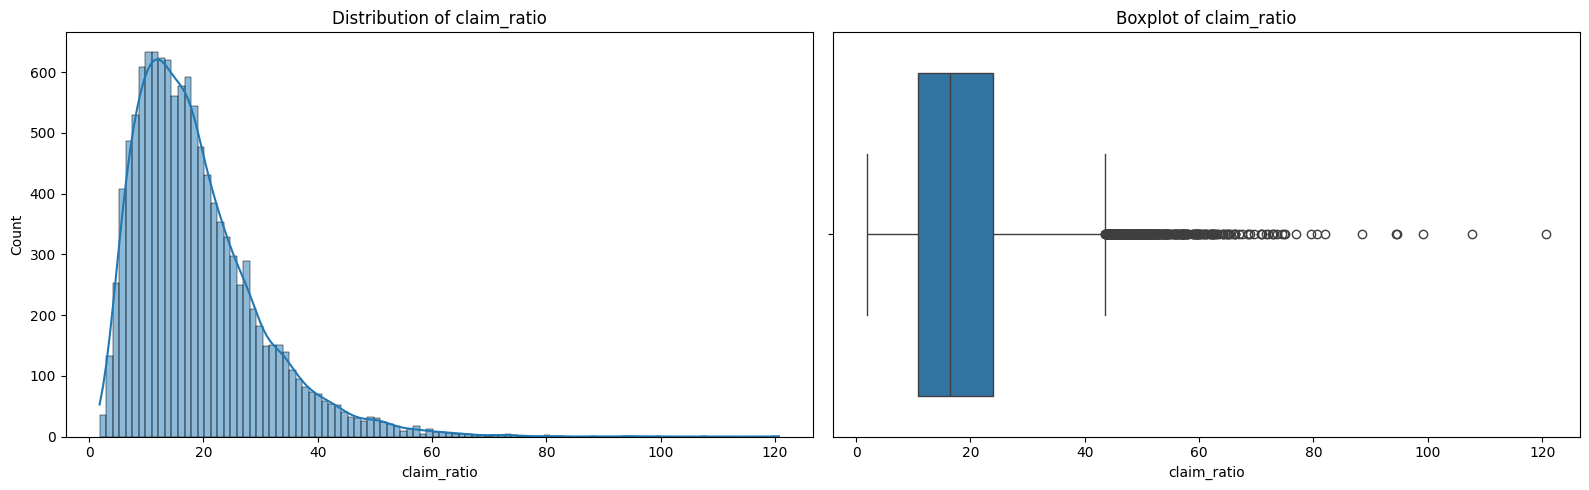

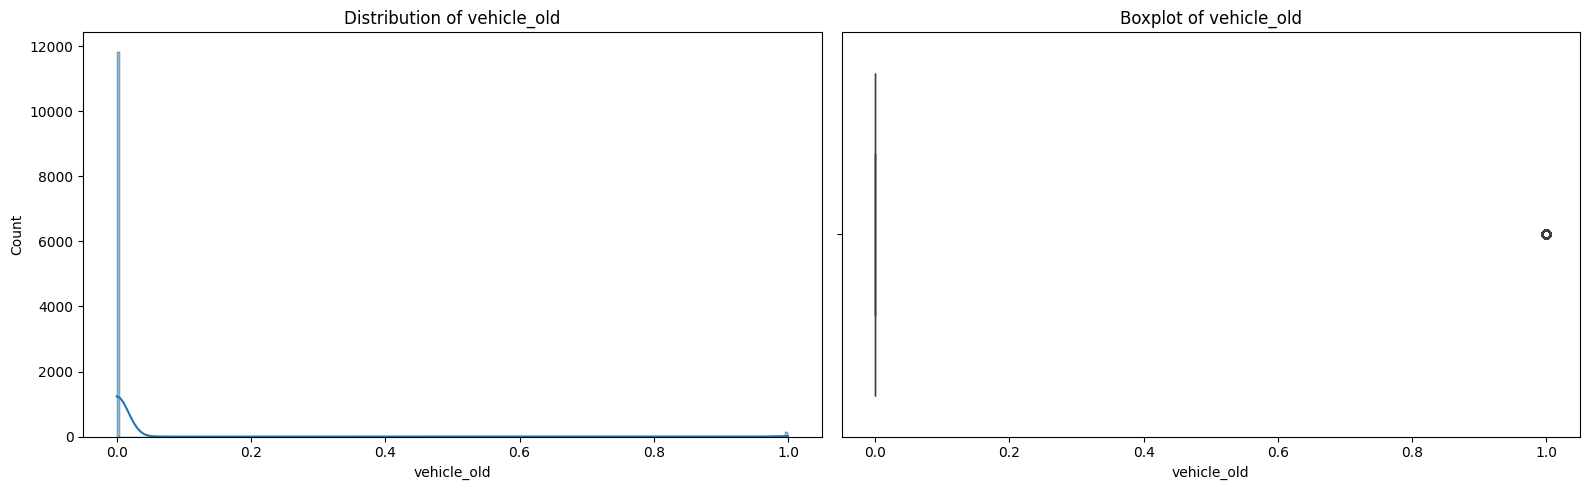

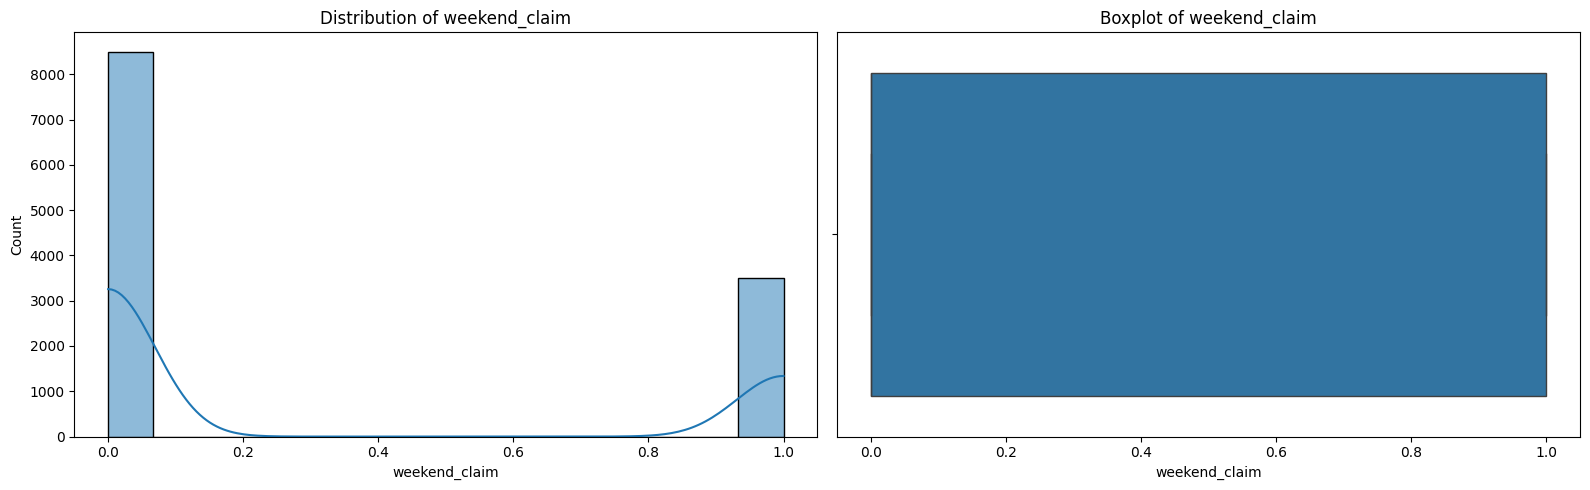

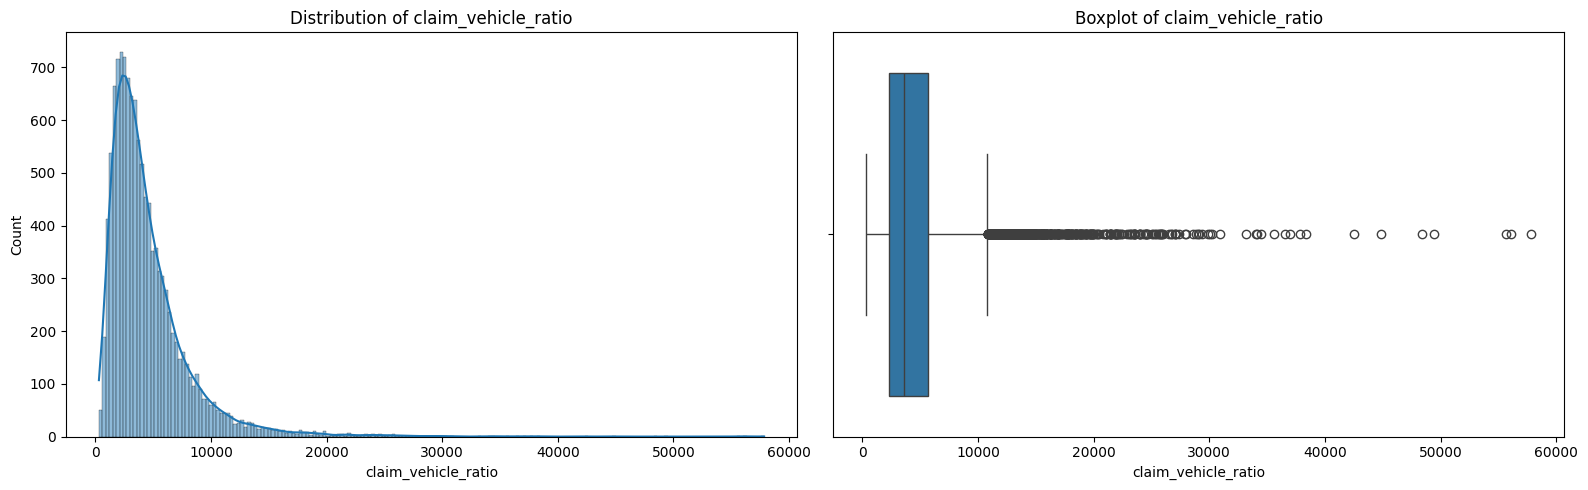

In [26]:
Numerical_columns = df.select_dtypes(include=np.number).columns

for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

## 9. Better Outlier Handling
Rather than dropping every outlier row (which throws away potentially useful data), skewed monetary columns are **log-transformed**, and the remaining numeric columns identified in the original analysis are **capped / winsorized** at their quantile or IQR bounds instead of being removed. This preserves the full row count.

In [27]:
# Log-transform strongly right-skewed monetary columns
for col in ["total_claim", "claim_vehicle_ratio", "vehicle_price"]:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

def cap_quantile(data, col, q):
    upper = data[col].quantile(q)
    data[col] = data[col].clip(upper=upper)
    return data

def cap_iqr(data, col, q1=0.25, q3=0.75):
    Q1, Q3 = data[col].quantile(q1), data[col].quantile(q3)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)
    return data

outlier_rules = {
    "age_of_driver": ("quantile", 0.99),
    "safety_rating": ("iqr", (0.25, 0.75)),
    "annual_income": ("iqr", (0.20, 0.80)),
    "annual_premium": ("iqr", (0.25, 0.75)),
    "days_open": ("iqr", (0.22, 0.78)),
}

for col, (method, param) in outlier_rules.items():
    if col in df.columns:
        df = cap_quantile(df, col, param) if method == "quantile" else cap_iqr(df, col, *param)

df.shape

(11994, 34)

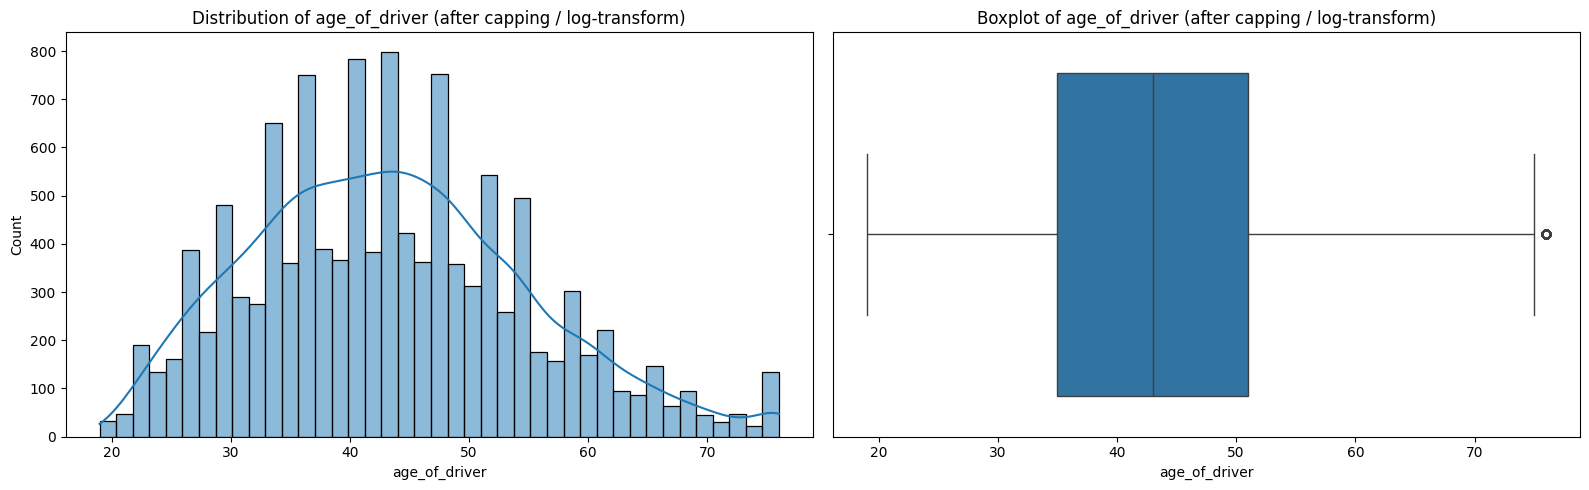

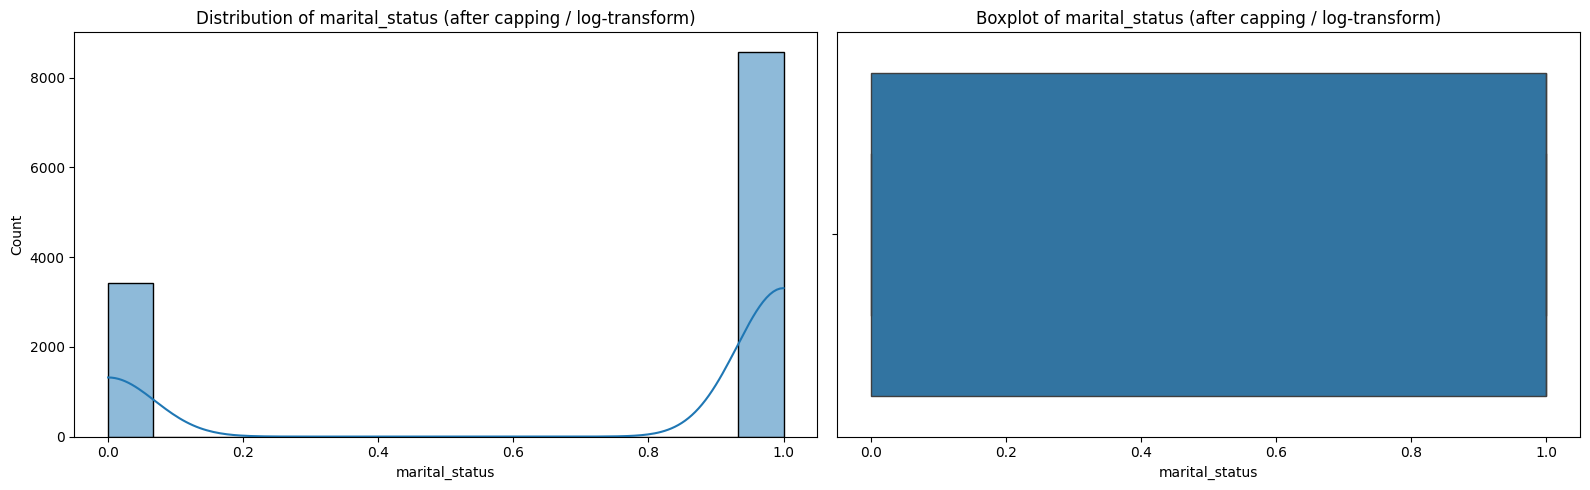

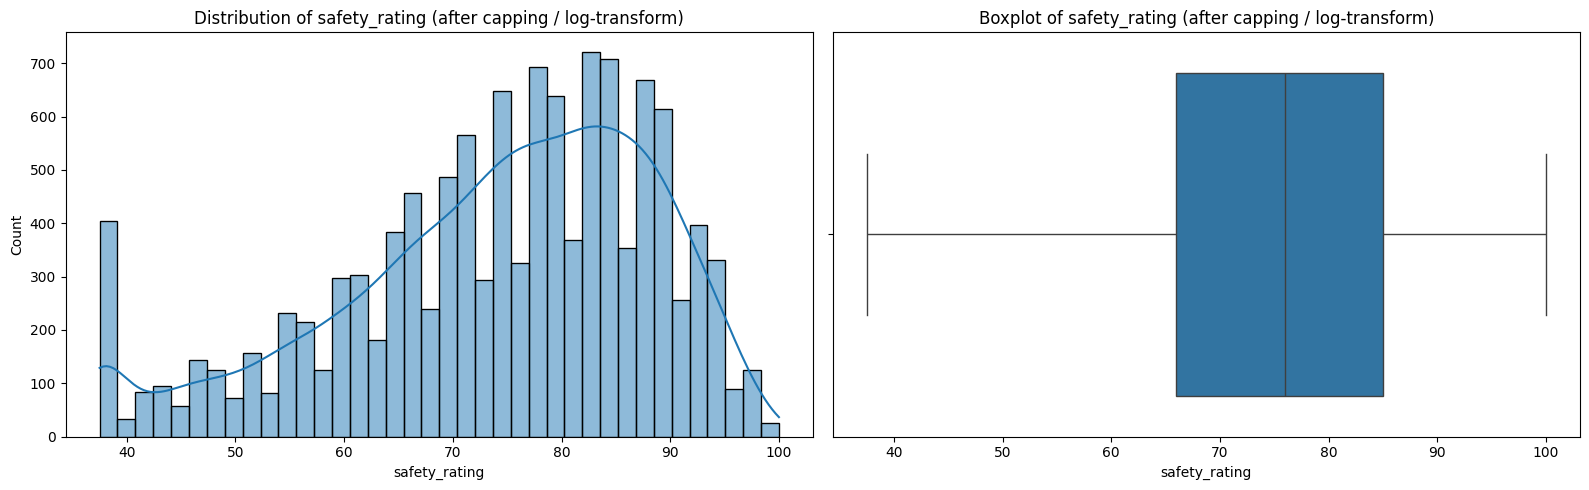

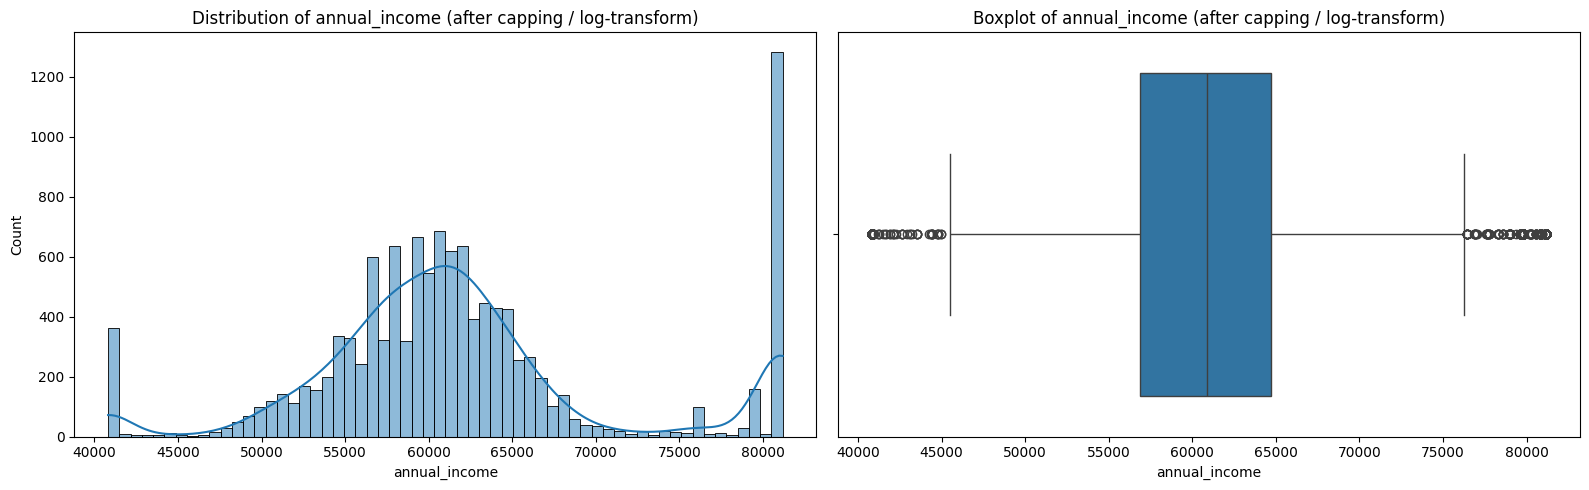

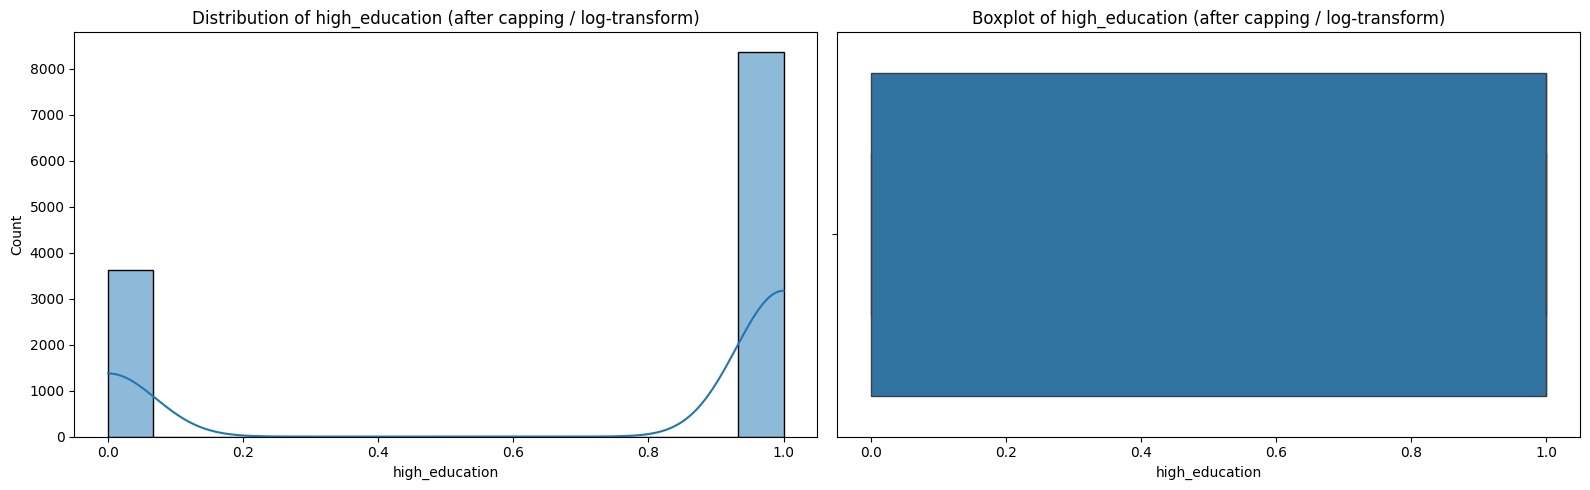

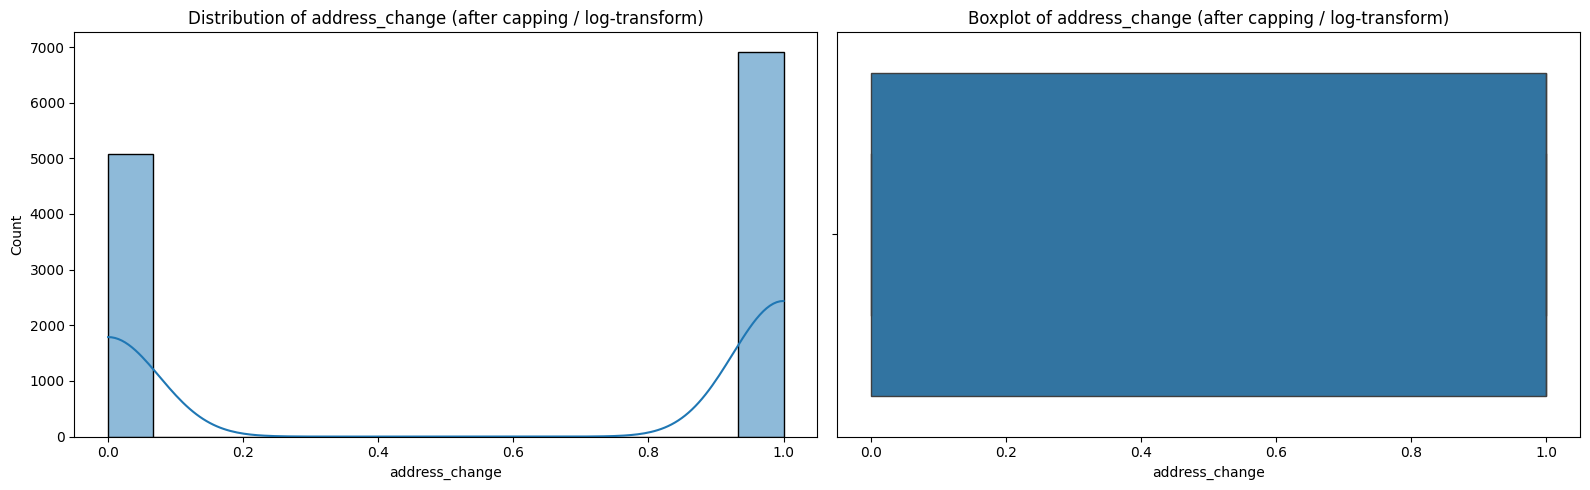

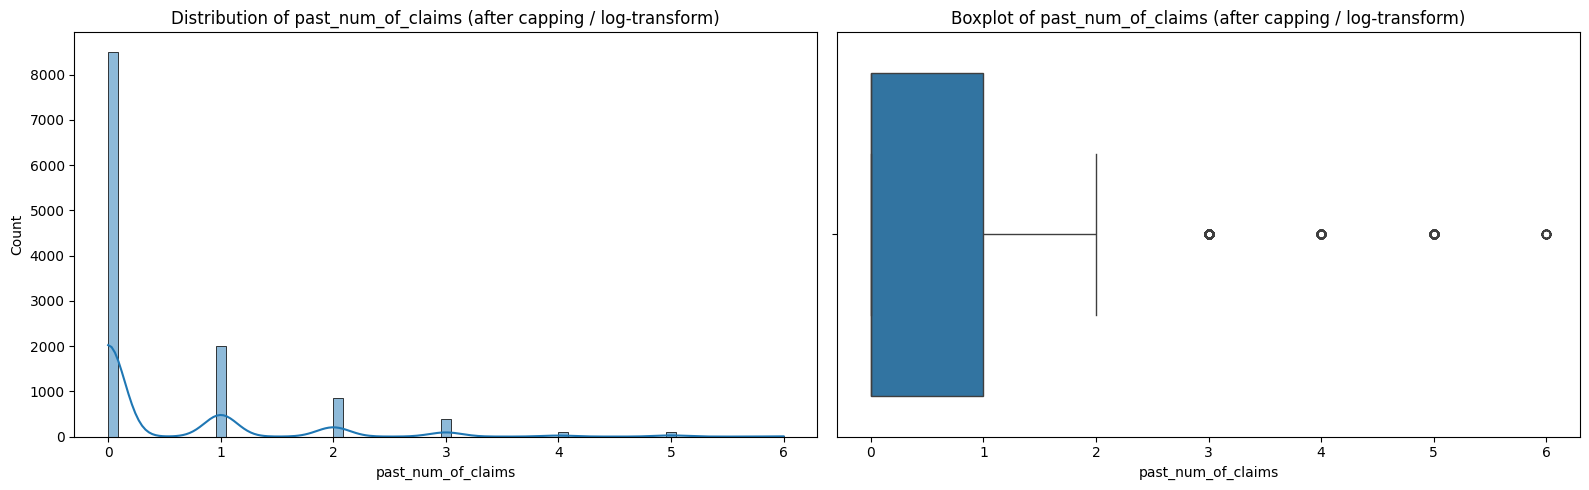

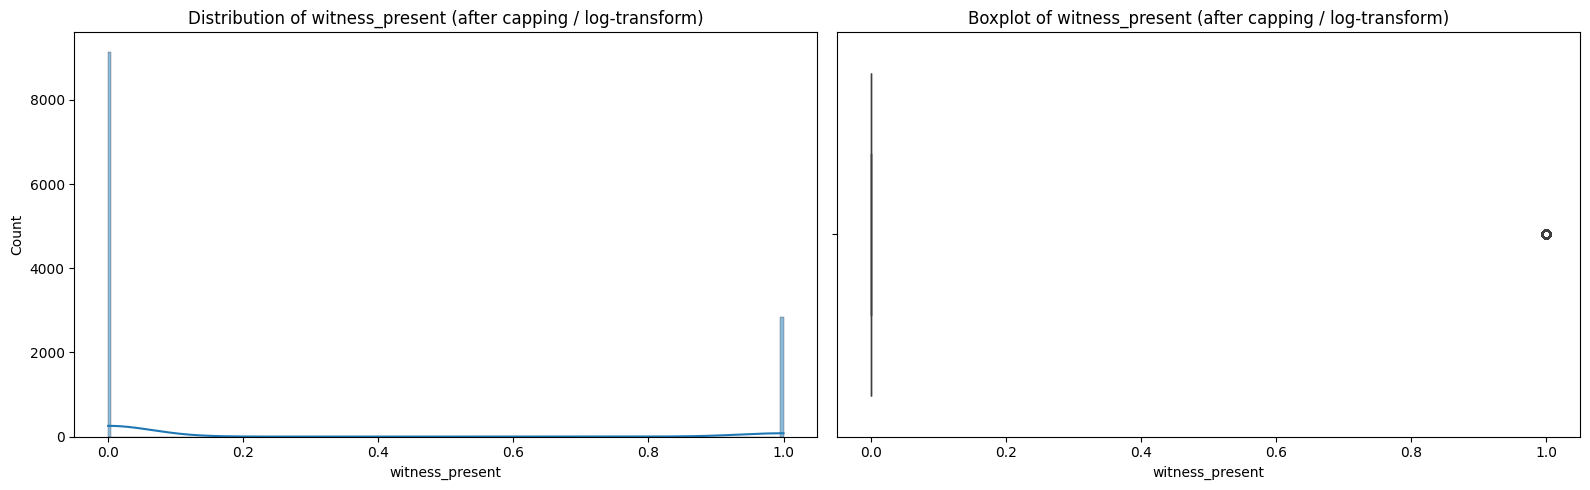

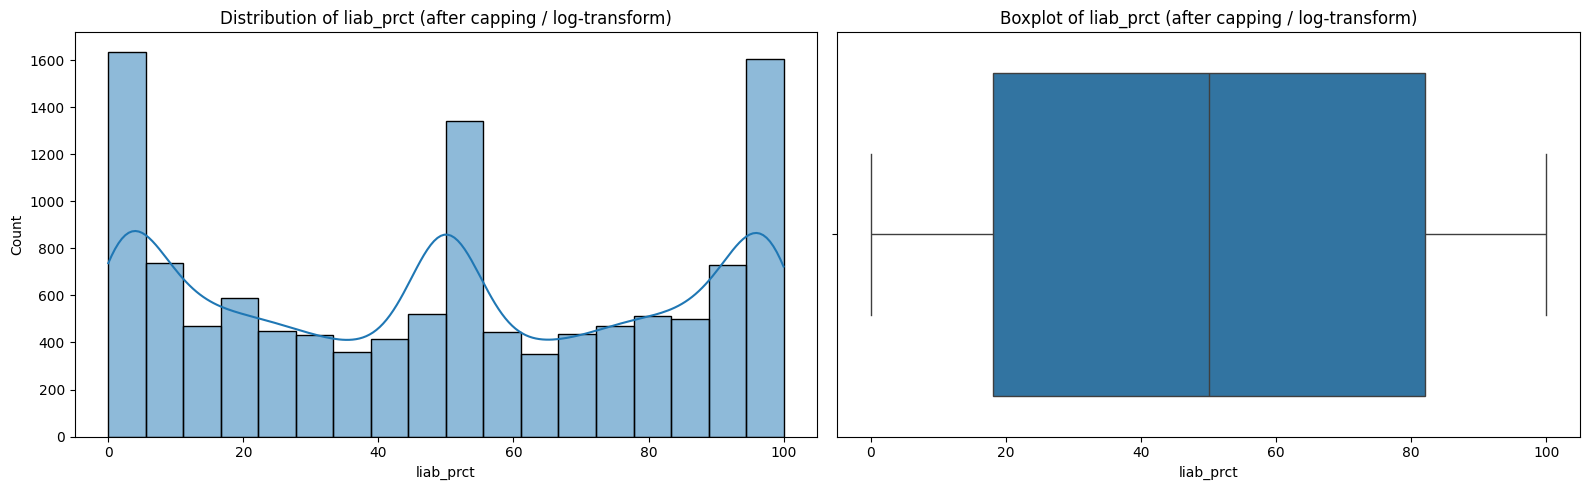

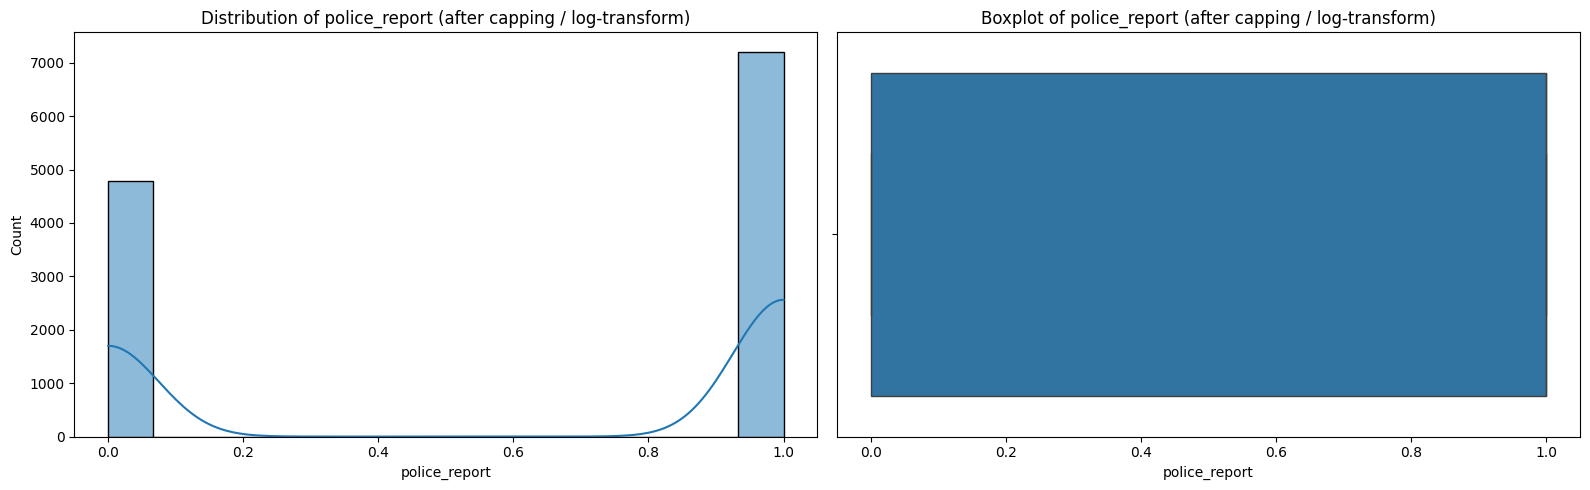

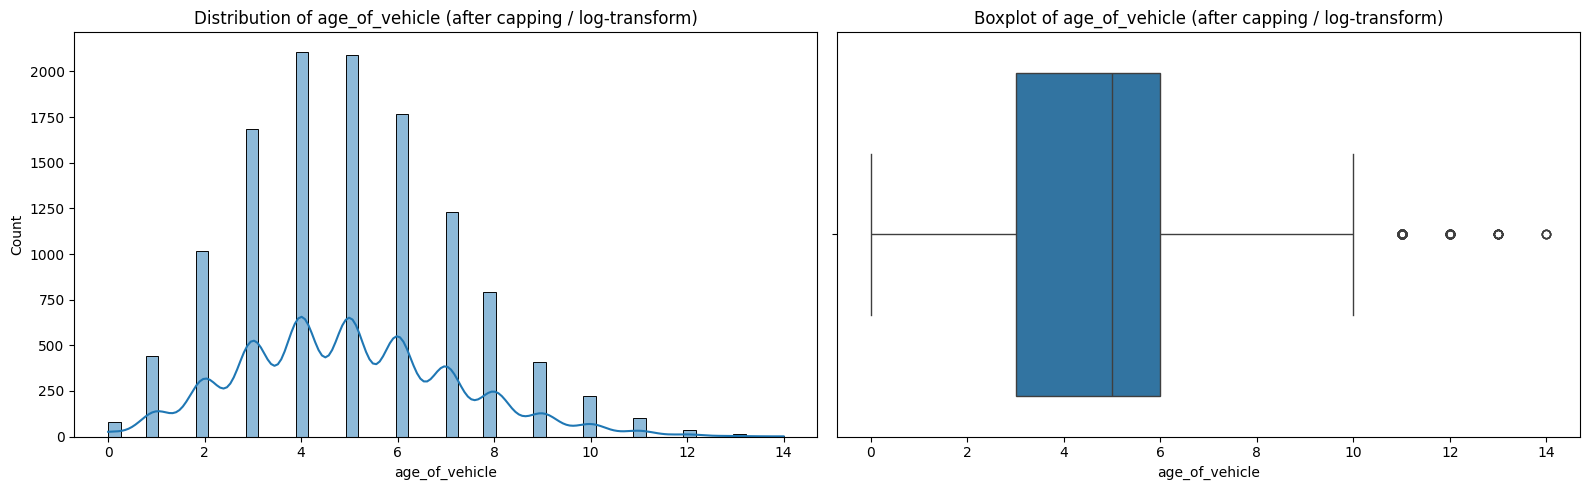

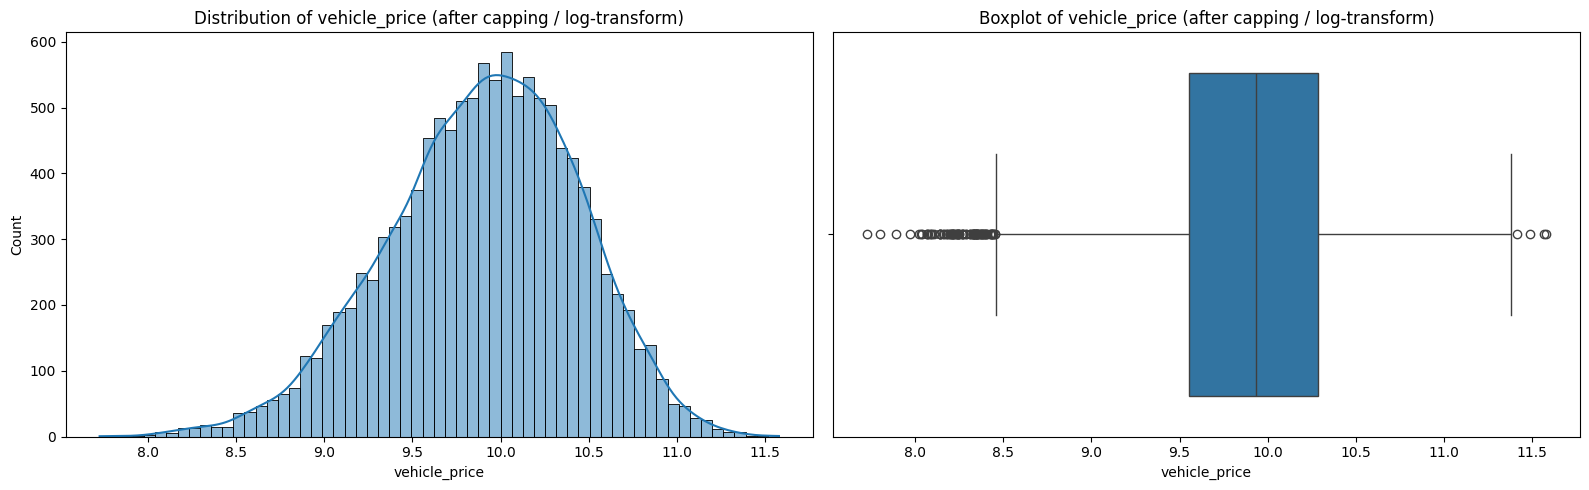

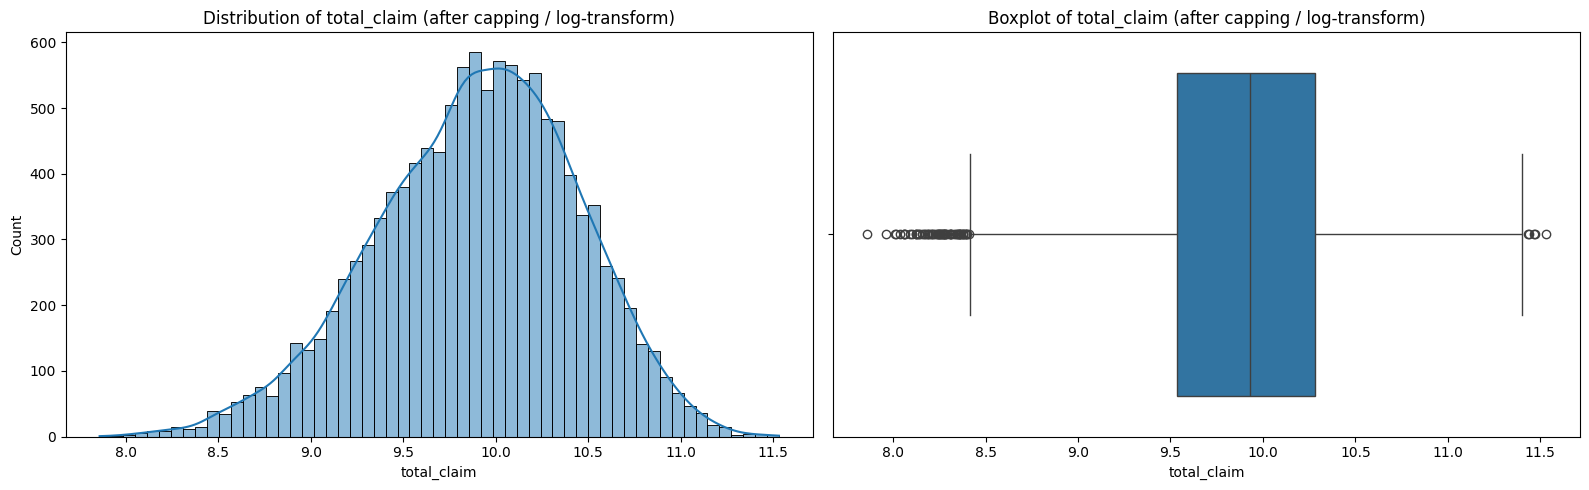

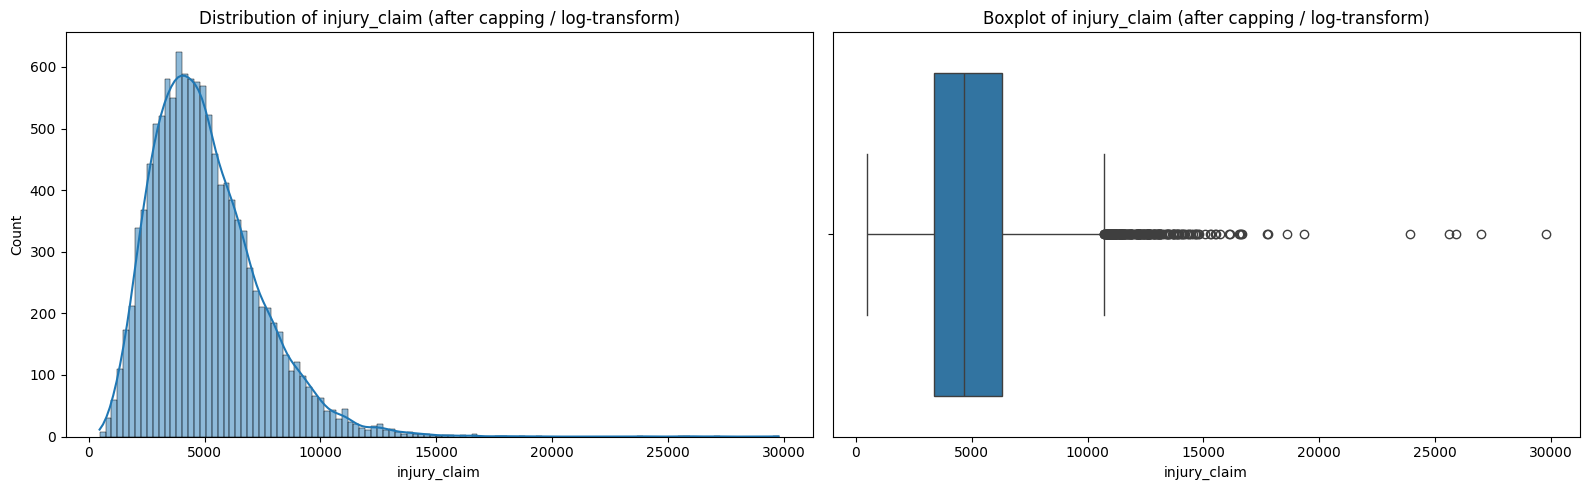

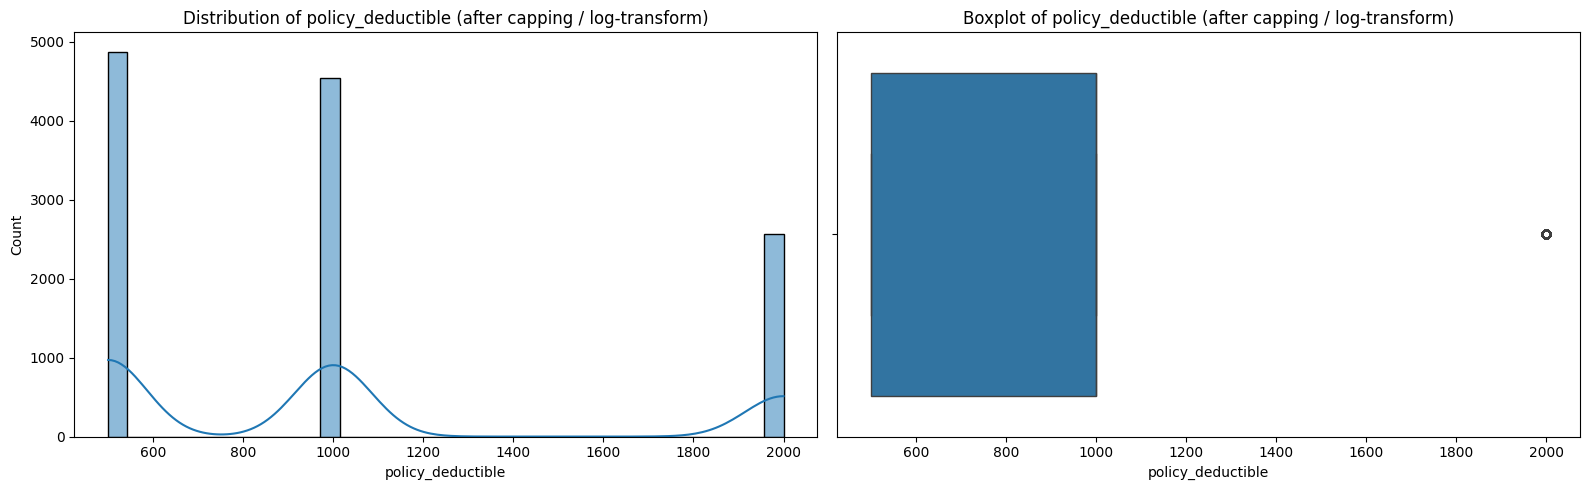

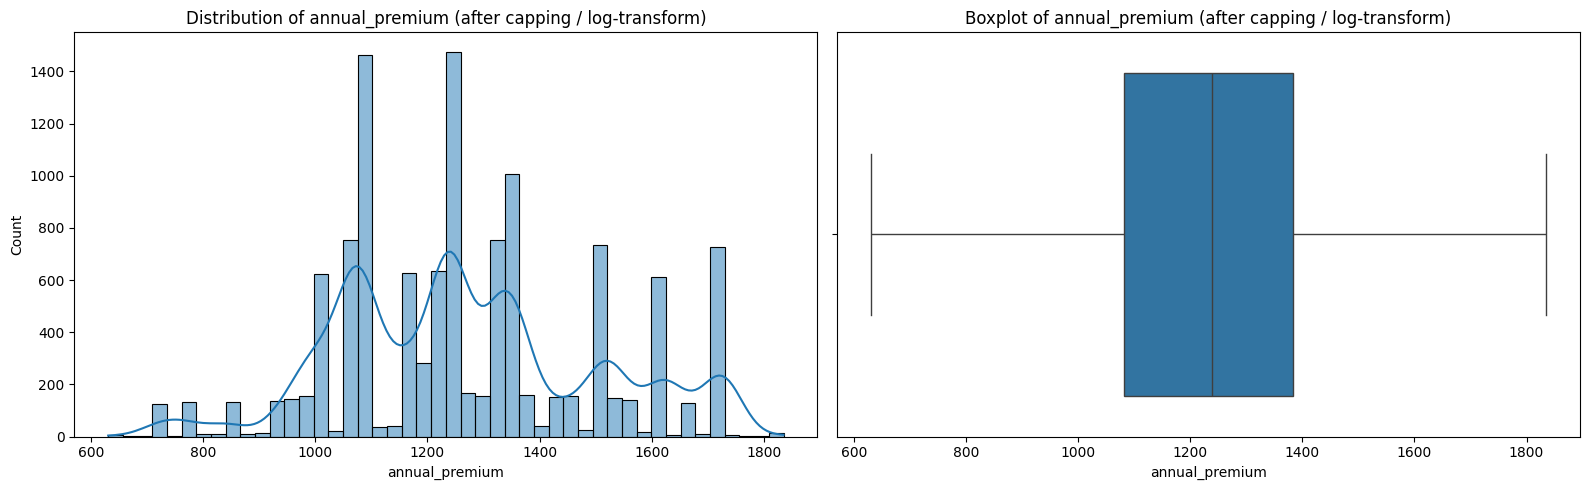

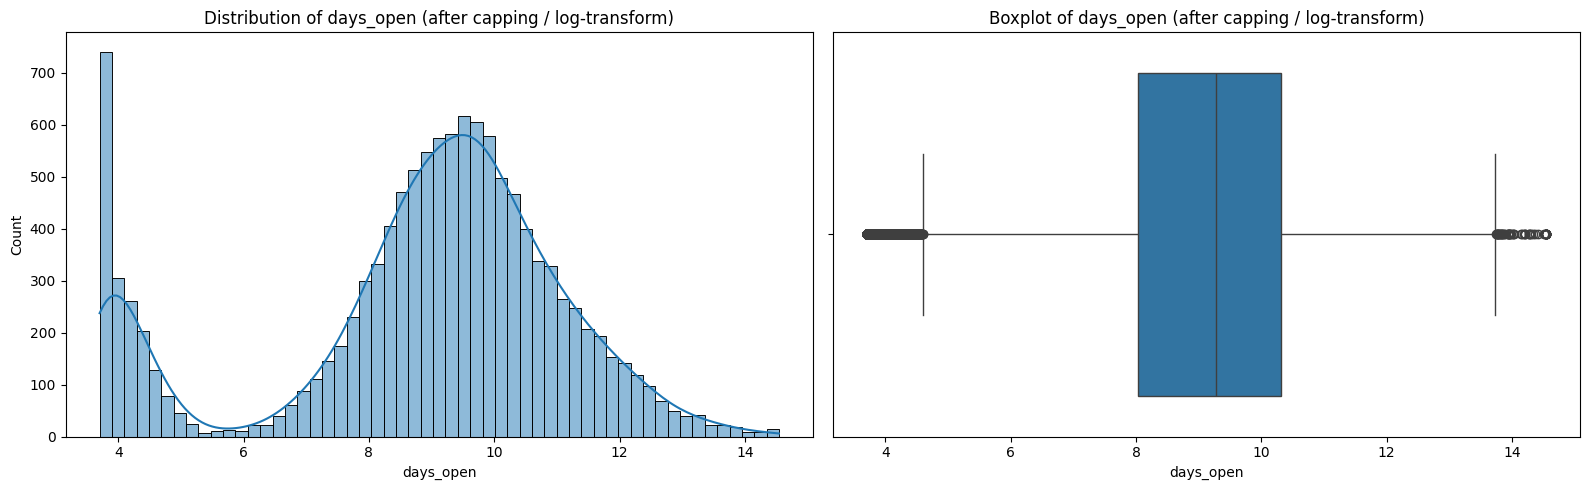

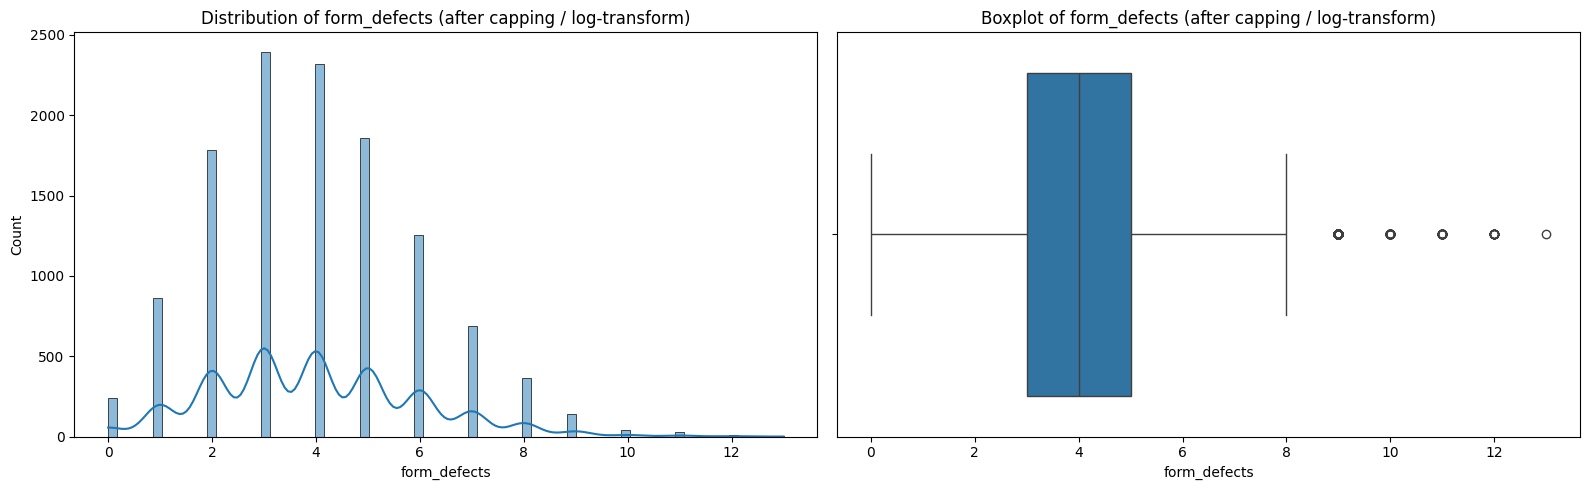

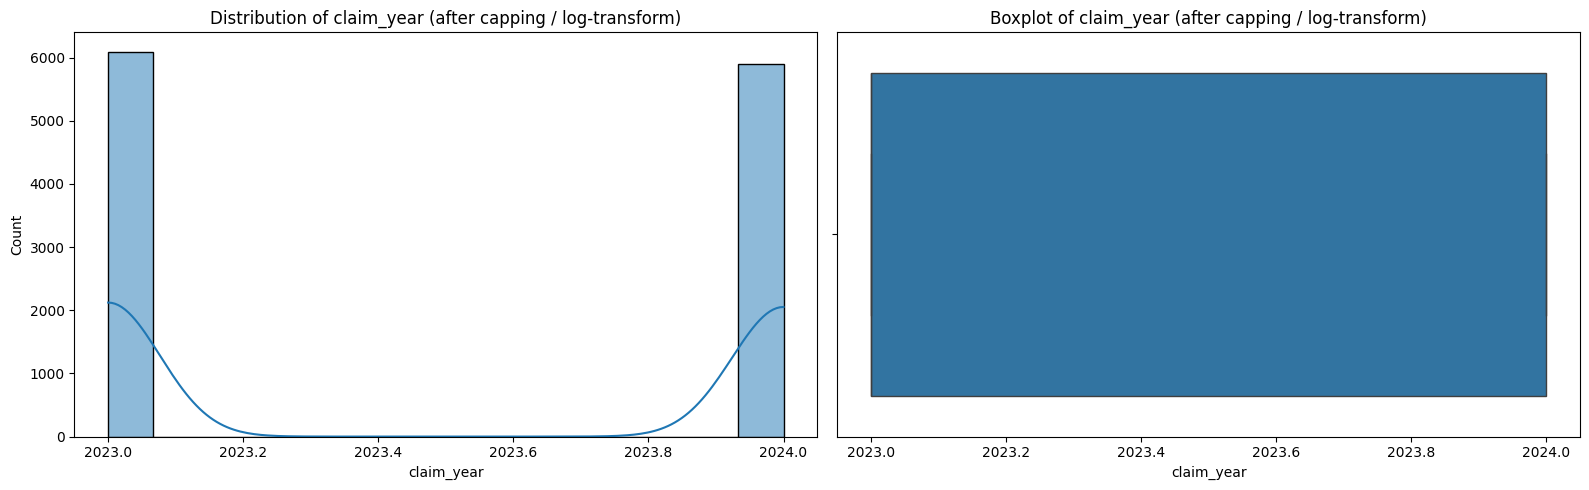

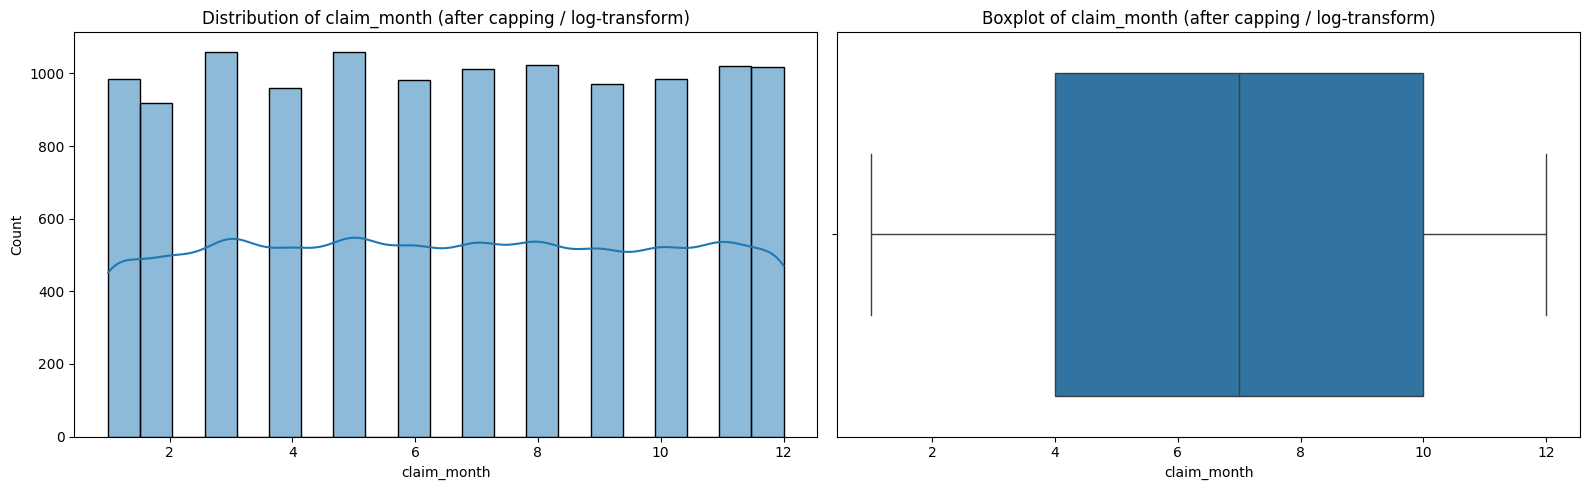

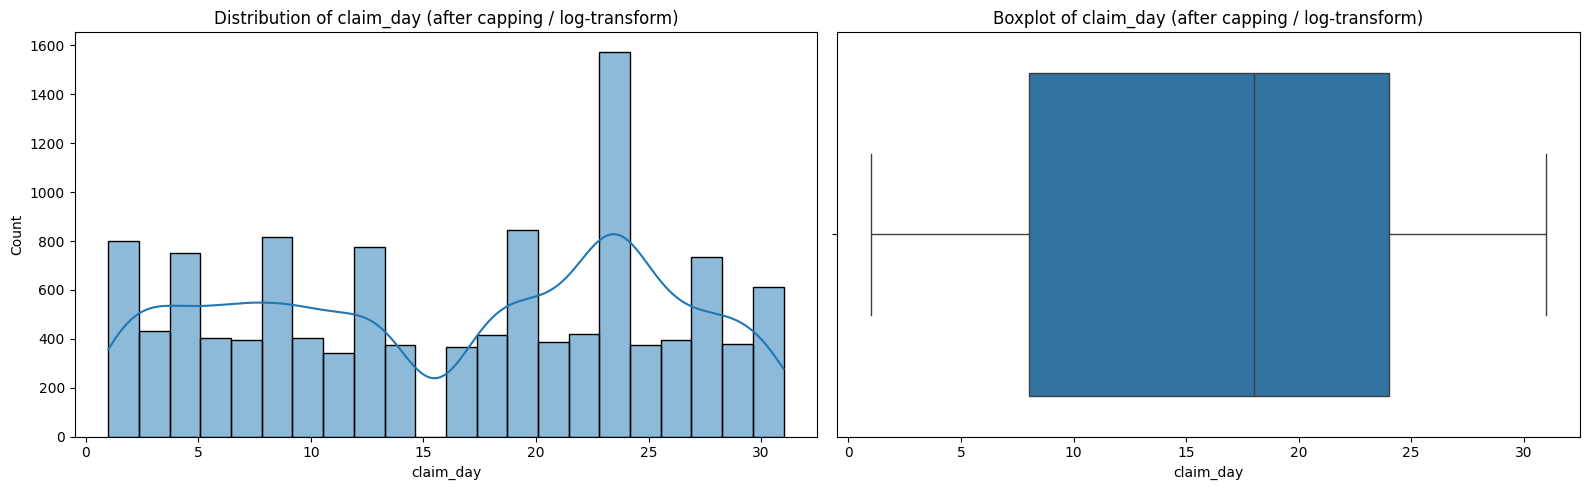

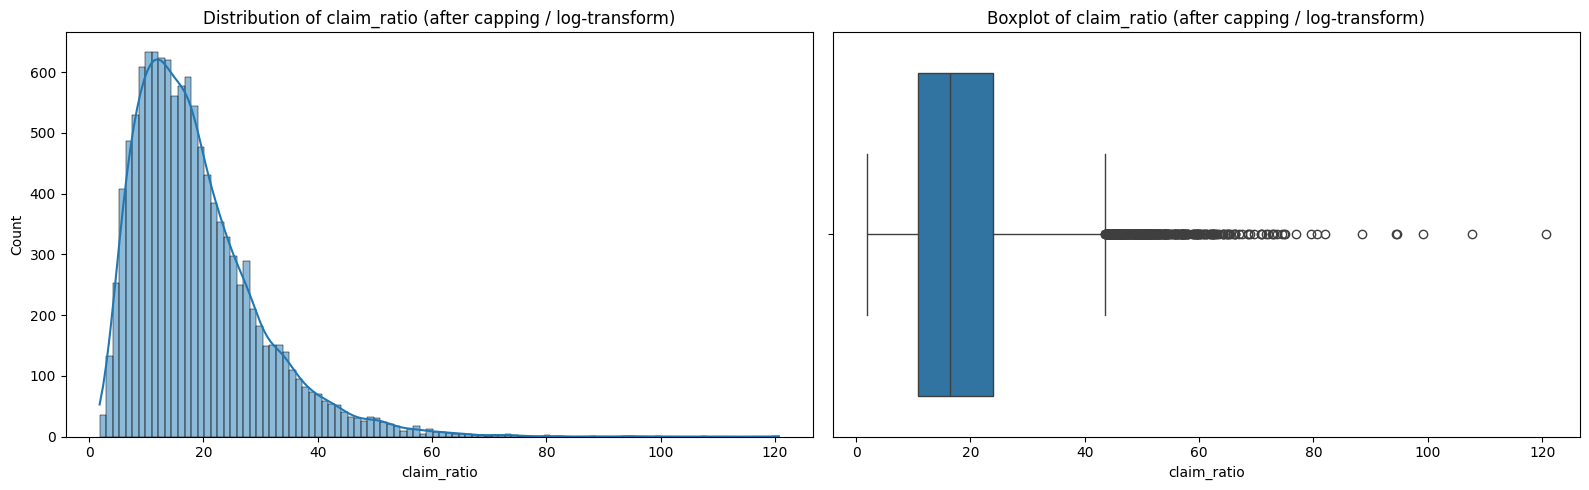

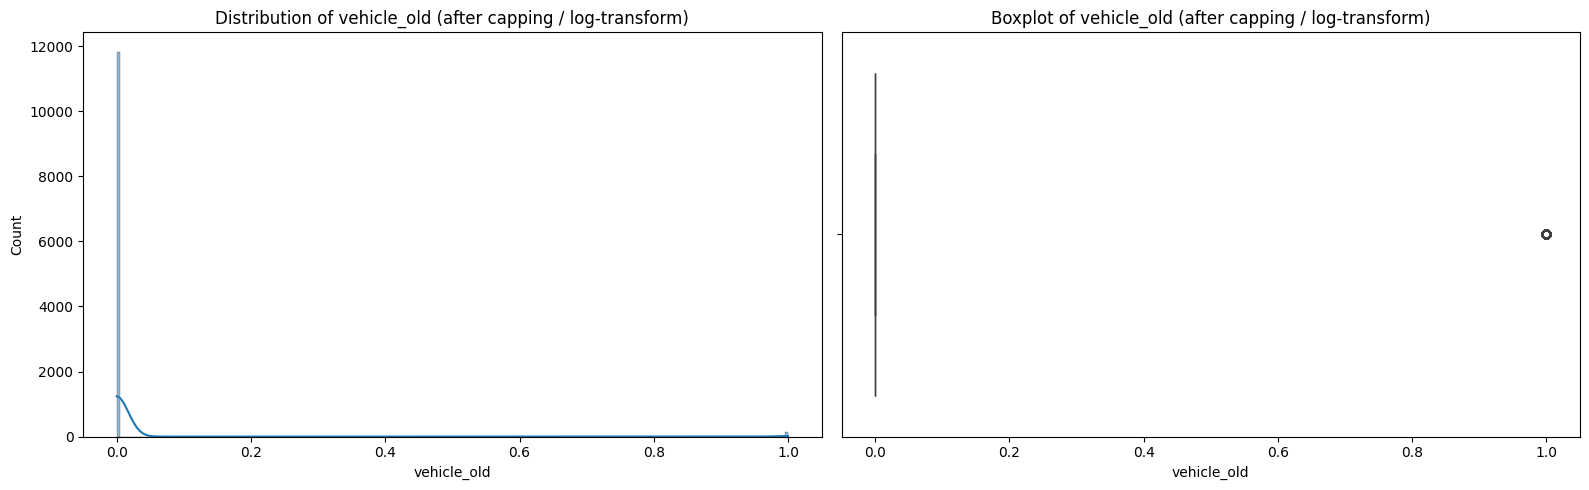

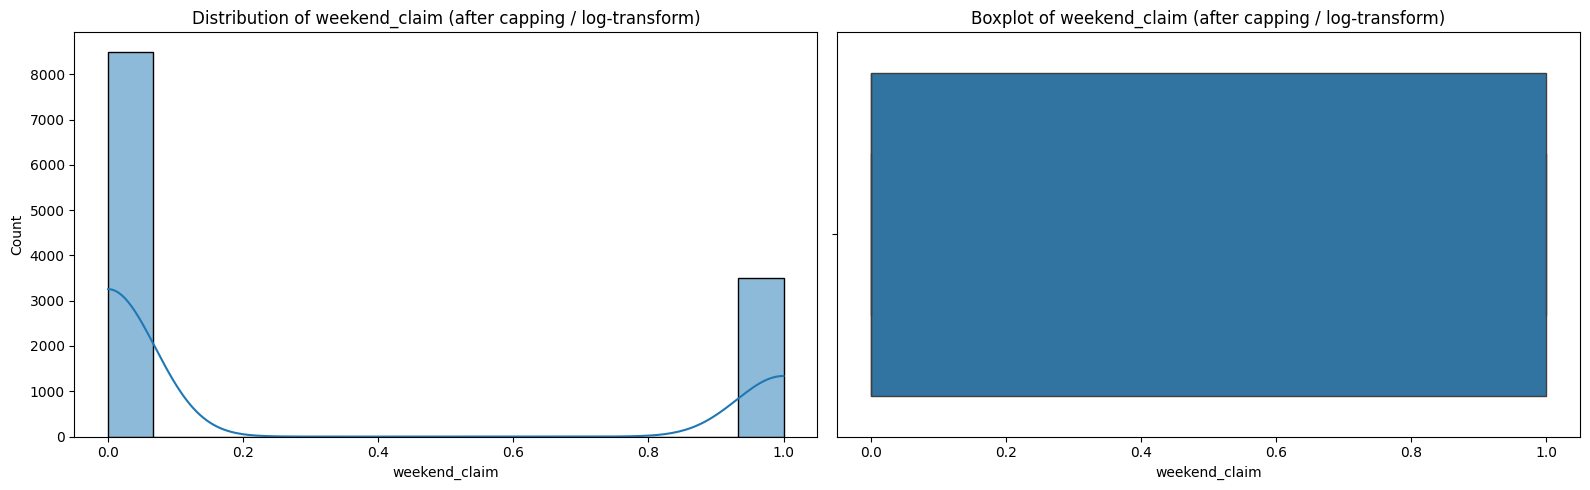

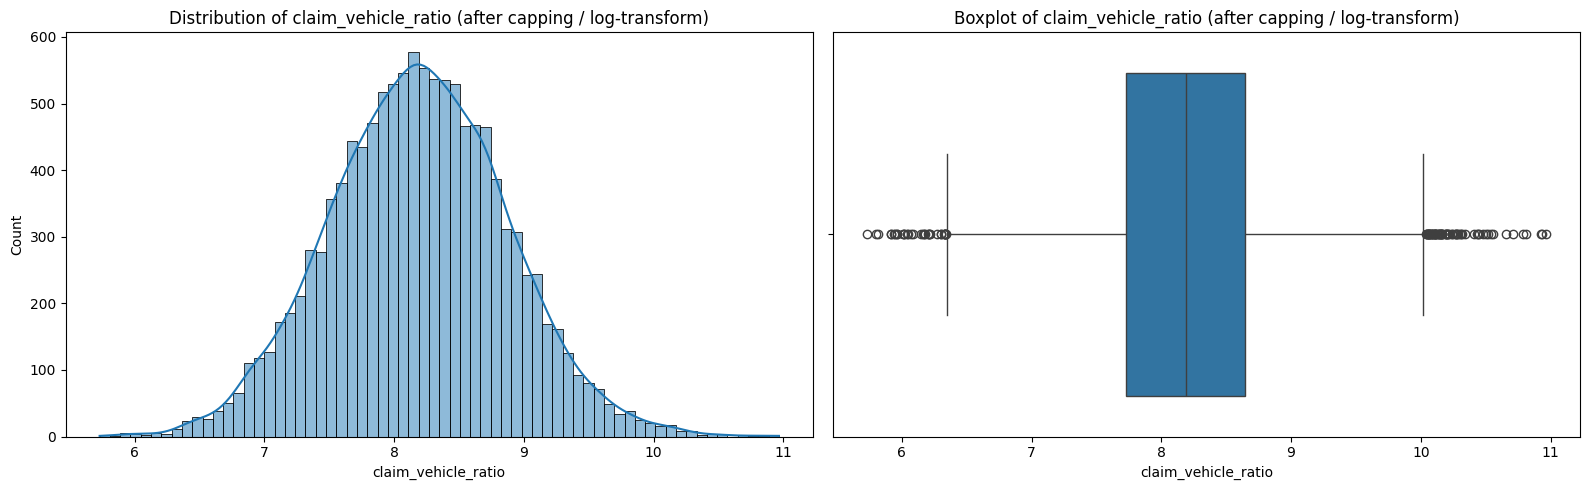

In [28]:
for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col} (after capping / log-transform)")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col} (after capping / log-transform)")
    plt.tight_layout()
    plt.show()

## 10. Feature / Target Split

In [29]:
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

## 11. Categorical Encoding
One-hot encoding for nominal columns (including the new `income_group` feature), ordinal encoding for `vehicle_category` (has a natural order), label encoding for the target. No train/test split happens here — the whole dataset is encoded together and split later, in whichever modeling notebook consumes this file.

In [30]:
ohe_columns = ["gender", "property_status", "claim_day_of_week", "accident_site",
                "channel", "vehicle_color", "income_group"]
ordinal_columns = ["vehicle_category"]

transformer = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ohe_columns),
    ("ord", OrdinalEncoder(categories=[["Compact", "Medium", "Large"]],
                            handle_unknown="use_encoded_value", unknown_value=-1), ordinal_columns)
], remainder="passthrough")

X_encoded = transformer.fit_transform(X)
feature_names = transformer.get_feature_names_out()
X_encoded = pd.DataFrame(X_encoded, columns=feature_names, index=X.index)

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), name="fraud_reported", index=y.index)

X_encoded.shape

(11994, 54)

## 12. Scale Numerical Features
Scaling matters for Logistic Regression, SVM, KNN, and Neural Networks.

In [31]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)

In [32]:
final_df = pd.concat([X_scaled, y_encoded], axis=1)
final_df.to_csv("insurance_fraud_data_preprocessed.csv", index=False)
final_df.shape

(11994, 55)